# setup

In [1]:
library(ChIPseeker)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(GenomicRanges)
library(ggplot2)
library(ggthemes)
library(dplyr)
library(stringr)
library(tools) # For file_path_sans_ext
library(colorspace)



ChIPseeker v1.42.1 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, and Qing-Yu He. ChIPseeker: an
R/Bioconductor package for ChIP peak annotation, comparison and
visualization. Bioinformatics. 2015, 31(14):2382-2383

Loading required package: GenomicFeatures

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading require

In [2]:
# [1] "TK-2746-1_S7.breaks"           "TK-2746-2_S8.breaks"          
# [3] "TK-2746-3_S9.breaks.filtered"  "TK-2746-4_S10.breaks.filtered"
# [5] "TK-2746-5_S11.breaks.filtered" "TK-2746-6_S12.breaks.filtered"
# [7] "TK-2746-7_S13.breaks.filtered" "TK-2746-8_S14.breaks.filtered"


read_counts = list(
"breaks-001"=342975,
"breaks-002-no-overlaps-nicks"= 388822,
"breaks-002-overlaps-nicks"= 388822,
"barcode01.breaks"=1772303,
"barcode02.breaks"=1538469,
"barcode03.breaks"=2900948,
"barcode04.breaks"=1561937,
"barcode07.breaks"=3808852,
"barcode08.breaks"=4033986,
"barcode09.breaks"=2969154,
"barcode10.breaks"=3544808,
"TK-2746-1_S7.breaks"=72745911,
"TK-2746-2_S8.breaks"=68231584,
"TK-2746-3_S9.breaks.filtered"=61827843,
"TK-2746-4_S10.breaks.filtered"=66612438,
"TK-2746-5_S11.breaks.filtered"=65807144,
"TK-2746-6_S12.breaks.filtered"=61293833,
"TK-2746-7_S13.breaks.filtered"=64172242,
"TK-2746-8_S14.breaks.filtered"=72118308,
"XI-4086-BMH-21_a"=447691254,
"XI-4086-BMH-21-TGF-b"=652252386,
"XI-4086-DMSO"=418676350,
"XI-4086-TGF-b"=641797871,
"filtered_BMH21_a"=447691254,
"filtered_BMH21_TGFb"=652252386,
"filtered_DMSO"=418676350,
"filtered_TGFb"=641797871
)

len_hg = 3.25e9

In [3]:
setwd("/workspace/eskiler/")

In [4]:
region_reads_string ="region	XI-4086-BMH-21_a	XI-4086-BMH-21-TGF-b	XI-4086-DMSO	XI-4086-TGF-b
Downstream (<=300bp)	300892858	446030858	287555238	425478078
1st Exon	1429408182	2120952065	1375823005	2035396248
1st Intron	30510945383	45183709967	29035508190	43699968132
5 UTR	183557273	274691763	177797619	262609238
Distal Intergenic	52794195681	76335075272	49333607732	75824192165
Other Exon	2457628341	3640351415	2355917429	3491791750
Other Intron	40843516188	60408121583	38830805759	58445342639
Promoter (<=1kb)	2138057403	3196165223	2091378350	3097746152
Promoter (1-2kb)	2414269957	3619015692	2351288923	3489398577
Promoter (2-3kb)	2428288209	3630809622	2348108034	3488456881
3 UTR	2303274142	3428230741	2205960086	3263489754"

# Read the data into a data frame using read.table()
region_reads <- read.table(text = region_reads_string, header = TRUE, sep = "\t")
# Rename UTR columns to match expected format
region_reads$region <- gsub("5 UTR", "5' UTR", region_reads$region)
region_reads$region <- gsub("3 UTR", "3' UTR", region_reads$region)

print(region_reads)
# Convert row names to a column
#region_reads$region <- rownames(region_reads)
#rownames(region_reads) <- NULL
# Convert all columns except 'region' to numeric

# Reorder columns to put region first

                 region XI.4086.BMH.21_a XI.4086.BMH.21.TGF.b XI.4086.DMSO
1  Downstream (<=300bp)        300892858            446030858    287555238
2              1st Exon       1429408182           2120952065   1375823005
3            1st Intron      30510945383          45183709967  29035508190
4                5' UTR        183557273            274691763    177797619
5     Distal Intergenic      52794195681          76335075272  49333607732
6            Other Exon       2457628341           3640351415   2355917429
7          Other Intron      40843516188          60408121583  38830805759
8      Promoter (<=1kb)       2138057403           3196165223   2091378350
9      Promoter (1-2kb)       2414269957           3619015692   2351288923
10     Promoter (2-3kb)       2428288209           3630809622   2348108034
11               3' UTR       2303274142           3428230741   2205960086
   XI.4086.TGF.b
1      425478078
2     2035396248
3    43699968132
4      262609238
5    7582419216

In [5]:
# --- 2. Setup TxDb and Calculate Genomic Region Widths (Run Once) ---

calculate_genomic_region_widths <- function(txdb) {
    cat("Calculating genomic region widths...\n")
    
    # Keep only canonical chromosomes
    canonical_chromosomes <- paste0("chr", c(1:22, "X", "Y"))
    seqlevelsStyle(txdb) <- "UCSC" # Ensure chromosome style matches (e.g., chr1 vs 1)
    txdb <- keepSeqlevels(txdb, canonical_chromosomes, pruning.mode = "coarse")

    # Define promoter regions relative to TSS
    # Using 3kb upstream and 3kb downstream as per original promoter definitions
    promoter_all <- getPromoters(TxDb=txdb, upstream=3000, downstream=3000)
    promoter1kb <- getPromoters(TxDb=txdb, upstream=1000, downstream=1000) # Corresponds to <=1kb label later
    promoter2kb <- getPromoters(TxDb=txdb, upstream=2000, downstream=2000) # Corresponds to <=2kb region

    # Reduce to get non-overlapping total widths for each definition
    promoter_all_width <- sum(width(reduce(promoter_all)))
    promoter1kb_width  <- sum(width(reduce(promoter1kb)))
    promoter2kb_width  <- sum(width(reduce(promoter2kb)))
    
    # Calculate widths for non-overlapping promoter bins:
    promoter_0_1kb_width <- promoter1kb_width # <=1kb
    promoter_1_2kb_width <- promoter2kb_width - promoter1kb_width # 1kb to 2kb
    promoter_2_3kb_width <- promoter_all_width - promoter2kb_width # 2kb to 3kb
    
    # Calculate 3'UTRs and 5'UTRs
    threeUTR <- threeUTRsByTranscript(txdb, use.names=TRUE) # Use names=T for potential unlisting issues
    threeUTR <- unlist(threeUTR)
    threeUTR_width <- sum(width(reduce(threeUTR)))

    fiveUTR <- fiveUTRsByTranscript(txdb, use.names=TRUE)
    fiveUTR <- unlist(fiveUTR)
    fiveUTR_width <- sum(width(reduce(fiveUTR)))

    # Calculate exons and split into first vs other
    exons_by_tx <- exonsBy(txdb, by="tx", use.names=TRUE)
    first_exons <- unlist(heads(exons_by_tx, n=1))
    first_exons_reduced <- reduce(first_exons)
    first_exons_width <- sum(width(first_exons_reduced))
    
    all_exons <- unlist(exons_by_tx)
    all_exons_reduced <- reduce(all_exons)
    all_exons_width <- sum(width(all_exons_reduced))
    
    # Other Exons = All Exons - First Exons (approximation, assumes minimal overlap issues after reduce)
    # A more precise way might involve setdiff, but this is often sufficient
    other_exons_width <- all_exons_width - first_exons_width
    # Ensure width is not negative due to potential edge cases in reduce/overlap
    other_exons_width <- max(0, other_exons_width) 

    # Calculate introns and split into first vs other
    introns_by_tx <- intronsByTranscript(txdb, use.names=TRUE)
    # Filter out transcripts with no introns
    introns_by_tx <- introns_by_tx[elementNROWS(introns_by_tx) > 0] 
    
    first_introns <- unlist(heads(introns_by_tx, n=1))
    first_introns_reduced <- reduce(first_introns)
    first_introns_width <- sum(width(first_introns_reduced))
    
    all_introns <- unlist(introns_by_tx)
    all_introns_reduced <- reduce(all_introns)
    all_introns_width <- sum(width(all_introns_reduced))

    # Other Introns = All Introns - First Introns
    other_introns_width <- all_introns_width - first_introns_width
    other_introns_width <- max(0, other_introns_width)

    # Calculate intergenic regions
    genes_reduced <- reduce(genes(txdb), ignore.strand=TRUE)
    intergenic <- gaps(genes_reduced)
    intergenic <- intergenic[strand(intergenic) == "*"] # Keep only gaps on reference sequences
    # Ensure intergenic regions are within the kept chromosome bounds
    intergenic <- keepSeqlevels(intergenic, seqlevels(txdb), pruning.mode="coarse")
    # It's possible gaps function creates ranges outside defined chromosome lengths, trim them
    seq_info <- seqinfo(txdb)
    intergenic <- trim(intergenic) 
    intergenic <- intergenic[width(intergenic) > 0] # Remove zero-width ranges potentially created by trim
    intergenic_width <- sum(width(reduce(intergenic))) # Reduce again after trimming/filtering

    # Calculate downstream regions (e.g., 300bp)
    downstream300 <- flank(genes(txdb), width=300, start=FALSE, ignore.strand=TRUE)
    downstream300 <- reduce(downstream300)
    # Need to remove parts overlapping genes or UTRs to make it more distinct
    # This simple definition overlaps with 3' UTRs and potentially intergenic space
    # For simplicity matching original code, we keep it, but acknowledge overlap
    downstream300_width <- sum(width(downstream300))

    # Create a data frame summarizing widths
    region_widths_df <- data.frame(
      region = c("Distal Intergenic", "Promoter (2-3kb)", "Promoter (1-2kb)", 
                 "Promoter (<=1kb)", "5' UTR", "1st Exon", "Other Exon", 
                 "1st Intron", "Other Intron", "3' UTR", "Downstream (<=300bp)"),
      width = c(intergenic_width, 
                promoter_2_3kb_width,  # 2-3kb
                promoter_1_2kb_width,  # 1-2kb
                promoter_0_1kb_width,  # 0-1kb
                fiveUTR_width, 
                first_exons_width, 
                other_exons_width, 
                first_introns_width, 
                other_introns_width, 
                threeUTR_width,
                downstream300_width)
    )
    
    # Handle potential negative widths arising from subtractions if overlaps were complex
    region_widths_df$width <- pmax(0, region_widths_df$width) 

    cat("Finished calculating widths.\n")
    print(region_widths_df)
    cat("Total Genome Width Considered (sum of parts):", sum(region_widths_df$width), "\n")
    
    return(region_widths_df)
}

# Execute the width calculation
txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene
genome_region_widths <- calculate_genomic_region_widths(txdb)


Calculating genomic region widths...


  27 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.

  27 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.



Finished calculating widths.
                 region      width
1     Distal Intergenic 1396457164
2      Promoter (2-3kb)   61183082
3      Promoter (1-2kb)   62127545
4      Promoter (<=1kb)   63469058
5                5' UTR   10591629
6              1st Exon   53456325
7            Other Exon  107286611
8            1st Intron  814025506
9          Other Intron 1020881974
10               3' UTR   50877352
11 Downstream (<=300bp)    9716994
Total Genome Width Considered (sum of parts): 3650073240 


In [6]:
# Get number of transcripts
num_transcripts <- length(transcripts(txdb))
cat("Number of transcripts:", num_transcripts, "\n")
# Get number of genes
num_genes <- length(genes(txdb))
cat("Number of genes:", num_genes, "\n")

num_transcripts <- 40375

Number of transcripts: 254033 


  27 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.



Number of genes: 32949 


In [6]:
# --- 3. Define Helper Functions (Annotation Reclassification & Plotting Theme) ---

# Create a function to reclassify the annotations
reclassify_annotation <- function(annotation) {
  # For exons
  if (grepl("exon", annotation, ignore.case = TRUE)) {
    if (grepl("exon 1 of", annotation, ignore.case = TRUE)) {
      return("1st Exon")
    } else {
      return("Other Exon")
    }
  }
  
  # For introns
  if (grepl("intron", annotation, ignore.case = TRUE)) {
    if (grepl("intron 1 of", annotation, ignore.case = TRUE)) {
      return("1st Intron")
    } else {
      return("Other Intron")
    }
  }
  
  # For promoters - already properly named in your data
  # For UTRs - already properly named in your data
  
  # Return original annotation if no match
  return(annotation)
}


# Define theme for publication-ready plots
theme_Publication <- function(base_size=12, base_family="sans") {
  library(grid)
  library(ggthemes)
  (theme_foundation(base_size=base_size, base_family=base_family)
   + theme(plot.title = element_text(face = "bold",
                                     size = rel(1.1), hjust = 0.5),
           plot.subtitle = element_text(size = rel(0.9), hjust = 0.5),
           text = element_text(),
           panel.background = element_rect(colour = NA),
           plot.background = element_rect(colour = NA),
           panel.border = element_rect(colour = NA),
           axis.title = element_text(face = "bold", size = rel(1)),
           axis.title.y = element_text(angle=90, vjust=2),
           axis.title.x = element_text(vjust = -0.2),
           axis.text = element_text(), 
           axis.line = element_line(colour="black"),
           axis.ticks = element_line(),
           #panel.grid.major = element_line(colour="#f0f0f0"),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank(),
           legend.key = element_rect(colour = NA),
           #legend.position = "none", # Usually removed as per original code request
           legend.position = "bottom", # Alternative
           legend.direction = "horizontal", # Alternative
           legend.key.size= unit(0.2, "cm"), # Alternative
           legend.margin = margin(0, 0, 0, 0, "cm"), # Alternative using margin
           legend.title = element_text(face="italic"),
           plot.margin=unit(c(10,5,5,5),"mm"),
           strip.background=element_rect(colour="#f0f0f0",fill="#f0f0f0"),
           strip.text = element_text(face="bold"),
           axis.text.x = element_text(angle = 45, hjust = 1, size = rel(0.85)), # Adjusted text size
           panel.grid.major.x = element_blank() # No vertical grid lines
     ))
}

# first test plots dont run

In [16]:
# --- 4. Define Core Analysis and Plotting Function ---

analyze_and_plot_regions <- function(bed_file_path, 
                                     txdb_obj, 
                                     region_widths_df, 
                                     output_dir, 
                                     tss_region = c(-3000, 0), # Define TSS region for annotation
                                     title_suffix = "",
                                     output_prefix = "SSB_frequency") {
    
    cat("Processing:", basename(bed_file_path), "\n")
    
    # --- 4a. Read BED and Annotate Peaks ---
    # Use tryCatch for basic error handling during file reading/annotation
    peakAnno <- tryCatch({
        # Read peak file (ChIPseeker handles gzipped BED)
        peak <- readPeakFile(bed_file_path, header = FALSE) 
        if (is.null(peak) || length(peak) == 0) {
           warning("No peaks found or error reading file: ", bed_file_path)
           return(NULL) # Skip this file
        }
        # Ensure seqlevels style matches TxDb
        seqlevelsStyle(peak) <- seqlevelsStyle(txdb_obj)[1] 
        
        # Annotate peaks
        annotatePeak(peak, 
                     TxDb = txdb_obj, 
                     tssRegion = tss_region, 
                     verbose = FALSE) # Suppress progress messages
    }, error = function(e) {
        warning("Error processing file ", bed_file_path, ": ", e$message)
        return(NULL) # Skip this file on error
    })
    
    # Check if annotation was successful
    if (is.null(peakAnno) || !is(peakAnno, "csAnno")) {
        cat("Skipping file due to read/annotation issues:", basename(bed_file_path), "\n")
        return(NULL)
    }
    
    # Convert annotation results to a data frame
    anno_df <- as.data.frame(peakAnno)
    
    if (nrow(anno_df) == 0) {
        cat("No annotations generated for:", basename(bed_file_path), "\n")
        return(NULL)
    }

    # --- 4b. Reclassify and Summarize ---
    anno_df$standardized_annotation <- sapply(anno_df$annotation, reclassify_annotation)
    
    # Count occurrences of each standardized annotation type
    annotation_counts <- anno_df %>%
      group_by(standardized_annotation) %>%
      summarise(count = n(), .groups = 'drop') %>%
      rename(region = standardized_annotation)

    # --- 4c. Prepare Data for Plotting ---
    # Join the counts with the pre-calculated genome region widths
    # Use a full_join to keep all genomic regions, even if they have 0 counts
    plot_data <- full_join(region_widths_df, annotation_counts, by = "region")
    
    # Replace NA counts with 0 and NA frequencies with 0
    plot_data$count[is.na(plot_data$count)] <- 0
    
    # Calculate frequency (SSBs per million nucleotides)
    # Avoid division by zero if width is 0 for any reason
    plot_data$frequency <- ifelse(plot_data$width > 0, 
                                  (plot_data$count / (plot_data$width / 1e6)), 
                                  0)
    
    # Calculate relative width for scaling bars (proportion of total calculated width)
    total_calc_width <- sum(region_widths_df$width)
    plot_data$rel_width <- plot_data$width / total_calc_width
    
    # --- 4d. Define Order and Colors ---
    # Define region order for the plot
    region_order <- c("Distal Intergenic", "Promoter (2-3kb)", "Promoter (1-2kb)", 
                    "Promoter (<=1kb)", "5' UTR", "1st Exon", "1st Intron", 
                    "Other Exon", "Other Intron", "3' UTR", "Downstream (<=300bp)")
    
    # Add any 'Other' category if present
    if ("Other" %in% plot_data$region) {
        region_order <- c(region_order, "Other")
    }
    
    # Ensure all regions in plot_data are in the order vector (handles 'Other' or unexpected)
    missing_regions <- setdiff(plot_data$region, region_order)
    full_region_order <- c(region_order, missing_regions)
    
    # Order the data frame according to the defined region order
    plot_data$region <- factor(plot_data$region, levels = full_region_order)
    plot_data <- plot_data %>% arrange(region)

    # Define custom colors
    custom_colors <- c(
    "Distal Intergenic"    = "#636EFA",  # Plotly Color 1 (Blue)
    "Promoter (2-3kb)"     = "#EF553B",  # Plotly Color 2 (Red/Orange)
    "Promoter (1-2kb)"     = "#00CC96",  # Plotly Color 3 (Green)
    "Promoter (<=1kb)"     = "#AB63FA",  # Plotly Color 4 (Purple)
    "5' UTR"               = "#FFA15A",  # Plotly Color 5 (Orange)
    "1st Exon"             = "#19D3F3",  # Plotly Color 6 (Cyan)
    "Other Exon"           = "#FF6692",  # Plotly Color 7 (Pink)
    "1st Intron"           = "#B6E880",  # Plotly Color 8 (Light Green)
    "Other Intron"         = "#FF97FF",  # Plotly Color 9 (Magenta)
    "3' UTR"               = "#FECB52",  # Plotly Color 10 (Yellow/Gold)
    "Downstream (<=300)"   = "#636EFA"   # Plotly Color 1 (Blue) - cycled
    )
    
    # Ensure colors exist for all factor levels
    plot_colors <- custom_colors[levels(plot_data$region)]
    names(plot_colors) <- levels(plot_data$region) # Important: Name the color vector

    # --- 4e. Calculate Bar Positions ---
    # Calculate cumulative widths for positioning bars along the x-axis
    #plot_data <- plot_data %>%
    #    mutate(
    #        xmax = cumsum(rel_width),
    #        xmin = xmax - rel_width,
    #        xcenter = xmin + (xmax - xmin) / 2 # For placing labels
    #    )
    plot_data$xmin <- c(0, cumsum(plot_data$rel_width)[-nrow(plot_data)])
    plot_data$xmax <- cumsum(plot_data$rel_width)
    # --- 4f. Create and Save Plot ---
    # Generate the plot title
    base_filename <- tools::file_path_sans_ext(basename(bed_file_path), compression = TRUE)
    plot_title <- paste0(base_filename, title_suffix)
    print(plot_data)
    # Create the plot
    pub_plot <- ggplot(plot_data) + 
      geom_rect(aes(xmin = xmin, xmax = xmax, 
                    ymin = 0, ymax = frequency, 
                    fill = region)) +
      scale_fill_manual(values = plot_colors) +
      labs(
        title = stringr::str_wrap(paste(plot_title, "- SSB Frequency by Genomic Region"), width=80),
        #subtitle = "Bar widths are proportional to region size in the genome",
        y = "SSBs per million nucleotides",
        x = "", # X-axis labels handled by scale_x_continuous
        caption = "Bar widths correspond to the relative size of genomic regions"
      ) + 
      scale_y_continuous(expand = expansion(mult = c(0, 0.05))) + # Expand y-axis slightly at top
      scale_x_continuous(
        breaks = plot_data$xmin + (plot_data$xmax - plot_data$xmin)/2,
        labels = plot_data$region,
        expand = c(0, 0)
      ) +
      theme_Publication(base_size = 11)
      # theme( axis.text.x = element_text(angle = 45, hjust = 1, size = rel(0.85))) # Already in theme_Publication

    # Ensure output directory exists
    if (!dir.exists(output_dir)) {
        dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
    }
      
    # Construct output filename
    output_filename_base <- file.path(output_dir, paste0(output_prefix, "_", base_filename, title_suffix))
    
    # Save the plot as PNG (adjust dimensions as needed)
    png_filename <- paste0(output_filename_base, ".png")
    ggsave(png_filename, pub_plot, width = 18, height = 6, dpi = 300, units = "in")
    cat("Saved plot:", png_filename, "\n")

    # Optionally save in other formats (uncomment if needed)
    # pdf_filename <- paste0(output_filename_base, ".pdf")
    # ggsave(pdf_filename, pub_plot, width = 10, height = 6, device = cairo_pdf) 
    
    # Return the plot object and the processed data for potential further use
    return(list(
      plot = pub_plot,
      data = plot_data
    ))
}

In [43]:
# --- 5. Main Execution - Process Files ---

# Define directories containing BED files
# Using relative paths from the script's location
# Adjust these paths if your script is in a different directory than /workspace/eskiler
bed_dirs <- c("faz1", "faz2") 
# Define the output directory for plots
output_plot_dir <- "frequency_plots_output"

# Find all gzipped BED files in the specified directories
all_bed_files <- list.files(path = bed_dirs, 
                            pattern = "\\.bed\\.gz$", 
                            full.names = TRUE, 
                            recursive = TRUE)
# Filter for the files you want to process (Example: TK- and barcode files)
# Modify the pattern if you need different files
#files_to_process <- grep("stranded/(TK-|barcode).*(fwd|rev)\\.bed\\.gz$", all_bed_files, value = TRUE)
files_to_process <- all_bed_files # Uncomment to process ALL found bed.gz files

cat("\nFound", length(all_bed_files), "total bed.gz files.")
cat("\nSelected", length(files_to_process), "files for processing:\n")
print(basename(files_to_process))

# Create a list to store results (plots and data)
results_list <- list()

# Loop through the selected files and generate plots
for (bed_file in files_to_process) {
    # Extract a base name for storing results, removing extensions
    result_name <- tools::file_path_sans_ext(basename(bed_file), compression = TRUE) 
    
    # Run the analysis and plotting function
    analysis_result <- analyze_and_plot_regions(
        bed_file_path = bed_file,
        txdb_obj = txdb,
        region_widths_df = genome_region_widths,
        output_dir = output_plot_dir
        # title_suffix = " - My Analysis", # Optional suffix for plot titles
        # output_prefix = "MyPrefix"     # Optional prefix for output files
    )
    
    # Store the result if analysis was successful
    if (!is.null(analysis_result)) {
        results_list[[result_name]] <- analysis_result
    }
}

cat("\nProcessing complete. Plots saved in:", output_plot_dir, "\n")

# You can now access individual results, e.g.:
# results_list[["TK-2746-1_S7.breaks.dedup.fwd"]]$plot
# results_list[["TK-2746-1_S7.breaks.dedup.fwd"]]$data


Found 46 total bed.gz files.
Selected 46 files for processing:
 [1] "breaks-001_forward.bed.gz"                     
 [2] "breaks-001_rc.bed.gz"                          
 [3] "breaks-002-no-overlaps-nicks_forward.bed.gz"   
 [4] "breaks-002-no-overlaps-nicks_rc.bed.gz"        
 [5] "breaks-002-overlaps-nicks_forward.bed.gz"      
 [6] "breaks-002-overlaps-nicks_rc.bed.gz"           
 [7] "barcode01.breaks.dedup.fwd.bed.gz"             
 [8] "barcode01.breaks.dedup.rev.bed.gz"             
 [9] "barcode02.breaks.dedup.fwd.bed.gz"             
[10] "barcode02.breaks.dedup.rev.bed.gz"             
[11] "barcode03.breaks.dedup.fwd.bed.gz"             
[12] "barcode03.breaks.dedup.rev.bed.gz"             
[13] "barcode04.breaks.dedup.fwd.bed.gz"             
[14] "barcode04.breaks.dedup.rev.bed.gz"             
[15] "barcode05.breaks.dedup.fwd.bed.gz"             
[16] "barcode05.breaks.dedup.rev.bed.gz"             
[17] "barcode06.breaks.dedup.fwd.bed.gz"             
[18] "barcode06.br

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

                 region      width count frequency   rel_width      xmin
1     Distal Intergenic 1396457164   563 0.4031631 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082    35 0.5720536 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545    34 0.5472613 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058    52 0.8192969 0.017388434 0.4163664
5                5' UTR   10591629    12 1.1329702 0.002901758 0.4337548
6              1st Exon   53456325    10 0.1870686 0.014645275 0.4366566
7            1st Intron  814025506   204 0.2506064 0.223016212 0.4513018
8            Other Exon  107286611    26 0.2423415 0.029393002 0.6743181
9          Other Intron 1020881974   489 0.4789976 0.279688079 0.7037111
10               3' UTR   50877352    12 0.2358613 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994     2 0.2058250 0.002662137 0.9973379
        xmax
1  0.3825833
2  0.3993455
3  0.4163664
4  0.4337548
5  0.4366566
6  0.4513018
7  0.6743181
8  0.7037111
9  0.98

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

                 region      width count frequency   rel_width      xmin
1     Distal Intergenic 1396457164   508 0.3637777 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082    19 0.3105434 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545    33 0.5311654 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058    41 0.6459841 0.017388434 0.4163664
5                5' UTR   10591629     6 0.5664851 0.002901758 0.4337548
6              1st Exon   53456325    18 0.3367235 0.014645275 0.4366566
7            1st Intron  814025506   232 0.2850034 0.223016212 0.4513018
8            Other Exon  107286611    32 0.2982665 0.029393002 0.6743181
9          Other Intron 1020881974   508 0.4976089 0.279688079 0.7037111
10               3' UTR   50877352    14 0.2751716 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994     3 0.3087375 0.002662137 0.9973379
        xmax
1  0.3825833
2  0.3993455
3  0.4163664
4  0.4337548
5  0.4366566
6  0.4513018
7  0.6743181
8  0.7037111
9  0.98

...

Skipping file due to read/annotation issues: GRCh38.nicks.fwd.dedup.rev.bed.gz 
Processing: GRCh38.nicks.rc.dedup.fwd.bed.gz 


Warning message in value[[3L]](cond):
“Error processing file faz2/GRCh38.nicks.rc.dedup.fwd.bed.gz: no lines available in input”


Skipping file due to read/annotation issues: GRCh38.nicks.rc.dedup.fwd.bed.gz 
Processing: GRCh38.nicks.rc.dedup.rev.bed.gz 


Warning message in value[[3L]](cond):
“Error processing file faz2/GRCh38.nicks.rc.dedup.rev.bed.gz: no lines available in input”


Skipping file due to read/annotation issues: GRCh38.nicks.rc.dedup.rev.bed.gz 
Processing: TK-2746-1_S7.breaks.dedup.fwd.bed.gz 
                 region      width count frequency   rel_width      xmin
1     Distal Intergenic 1396457164  3485  2.495601 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082   213  3.481355 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545   235  3.782541 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058   468  7.373672 0.017388434 0.4163664
5                5' UTR   10591629    40  3.776567 0.002901758 0.4337548
6              1st Exon   53456325   100  1.870686 0.014645275 0.4366566
7            1st Intron  814025506  1504  1.847608 0.223016212 0.4513018
8            Other Exon  107286611   164  1.528616 0.029393002 0.6743181
9          Other Intron 1020881974  3428  3.357881 0.279688079 0.7037111
10               3' UTR   50877352   165  3.243093 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994    17  1.749512 0.002662137 0.997

In [44]:
# --- 5. Main Execution - Process Files ---

# Define directories containing BED files
# Using relative paths from the script's location
# Adjust these paths if your script is in a different directory than /workspace/eskiler
bed_dirs <- c("together") 
# Define the output directory for plots
output_plot_dir <- "frequency_plots_both_strands_output"

# Find all gzipped BED files in the specified directories
all_bed_files <- list.files(path = bed_dirs, 
                            pattern = "\\.bed\\.gz$", 
                            full.names = TRUE, 
                            recursive = TRUE)
# Filter for the files you want to process (Example: TK- and barcode files)
# Modify the pattern if you need different files
#files_to_process <- grep("stranded/(TK-|barcode).*(fwd|rev)\\.bed\\.gz$", all_bed_files, value = TRUE)
files_to_process <- all_bed_files # Uncomment to process ALL found bed.gz files

cat("\nFound", length(all_bed_files), "total bed.gz files.")
cat("\nSelected", length(files_to_process), "files for processing:\n")
print(basename(files_to_process))

# Create a list to store results (plots and data)
results_list <- list()

# Loop through the selected files and generate plots
for (bed_file in files_to_process) {
    # Extract a base name for storing results, removing extensions
    result_name <- tools::file_path_sans_ext(basename(bed_file), compression = TRUE) 
    
    # Run the analysis and plotting function
    analysis_result <- analyze_and_plot_regions(
        bed_file_path = bed_file,
        txdb_obj = txdb,
        region_widths_df = genome_region_widths,
        output_dir = output_plot_dir
        # title_suffix = " - My Analysis", # Optional suffix for plot titles
        # output_prefix = "MyPrefix"     # Optional prefix for output files
    )
    
    # Store the result if analysis was successful
    if (!is.null(analysis_result)) {
        results_list[[result_name]] <- analysis_result
    }
}

cat("\nProcessing complete. Plots saved in:", output_plot_dir, "\n")

# You can now access individual results, e.g.:
# results_list[["TK-2746-1_S7.breaks.dedup.fwd"]]$plot
# results_list[["TK-2746-1_S7.breaks.dedup.fwd"]]$data


Found 23 total bed.gz files.
Selected 23 files for processing:
 [1] "barcode01.breaks.dedup.both.bed.gz"             
 [2] "barcode02.breaks.dedup.both.bed.gz"             
 [3] "barcode03.breaks.dedup.both.bed.gz"             
 [4] "barcode04.breaks.dedup.both.bed.gz"             
 [5] "barcode05.breaks.dedup.both.bed.gz"             
 [6] "barcode06.breaks.dedup.both.bed.gz"             
 [7] "barcode07.breaks.dedup.both.bed.gz"             
 [8] "barcode08.breaks.dedup.both.bed.gz"             
 [9] "barcode09.breaks.dedup.both.bed.gz"             
[10] "barcode10.breaks.dedup.both.bed.gz"             
[11] "breaks-001.bed.gz"                              
[12] "breaks-002-no-overlaps-nicks.bed.gz"            
[13] "breaks-002-overlaps-nicks.bed.gz"               
[14] "GRCh38.nicks.fwd.dedup.both.bed.gz"             
[15] "GRCh38.nicks.rc.dedup.both.bed.gz"              
[16] "TK-2746-1_S7.breaks.dedup.both.bed.gz"          
[17] "TK-2746-2_S8.breaks.dedup.both.bed.gz"          
[

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

                 region      width count frequency   rel_width      xmin
1     Distal Intergenic 1396457164  1071 0.7669408 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082    54 0.8825969 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545    67 1.0784266 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058    93 1.4652809 0.017388434 0.4163664
5                5' UTR   10591629    18 1.6994553 0.002901758 0.4337548
6              1st Exon   53456325    28 0.5237921 0.014645275 0.4366566
7            1st Intron  814025506   436 0.5356098 0.223016212 0.4513018
8            Other Exon  107286611    58 0.5406080 0.029393002 0.6743181
9          Other Intron 1020881974   997 0.9766065 0.279688079 0.7037111
10               3' UTR   50877352    26 0.5110329 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994     5 0.5145624 0.002662137 0.9973379
        xmax
1  0.3825833
2  0.3993455
3  0.4163664
4  0.4337548
5  0.4366566
6  0.4513018
7  0.6743181
8  0.7037111
9  0.98

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

                 region      width count frequency   rel_width      xmin
1     Distal Intergenic 1396457164  1343 0.9617194 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082    61 0.9970076 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545    72 1.1589062 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058    80 1.2604567 0.017388434 0.4163664
5                5' UTR   10591629     5 0.4720709 0.002901758 0.4337548
6              1st Exon   53456325    20 0.3741372 0.014645275 0.4366566
7            1st Intron  814025506   528 0.6486283 0.223016212 0.4513018
8            Other Exon  107286611    35 0.3262290 0.029393002 0.6743181
9          Other Intron 1020881974  1241 1.2156155 0.279688079 0.7037111
10               3' UTR   50877352    39 0.7665493 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994     3 0.3087375 0.002662137 0.9973379
        xmax
1  0.3825833
2  0.3993455
3  0.4163664
4  0.4337548
5  0.4366566
6  0.4513018
7  0.6743181
8  0.7037111
9  0.98

...

                 region      width count  frequency   rel_width      xmin
1     Distal Intergenic 1396457164    57 0.04081758 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082     0 0.00000000 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545     2 0.03219184 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058     6 0.09453425 0.017388434 0.4163664
5                5' UTR   10591629     2 0.18882837 0.002901758 0.4337548
6              1st Exon   53456325     1 0.01870686 0.014645275 0.4366566
7            1st Intron  814025506    29 0.03562542 0.223016212 0.4513018
8            Other Exon  107286611     7 0.06524579 0.029393002 0.6743181
9          Other Intron 1020881974    59 0.05779316 0.279688079 0.7037111
10               3' UTR   50877352     7 0.13758578 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994     0 0.00000000 0.002662137 0.9973379
        xmax
1  0.3825833
2  0.3993455
3  0.4163664
4  0.4337548
5  0.4366566
6  0.4513018
7  0.6743181
8  0.703

Warning message in value[[3L]](cond):
“Error processing file together/GRCh38.nicks.fwd.dedup.both.bed.gz: no lines available in input”


Skipping file due to read/annotation issues: GRCh38.nicks.fwd.dedup.both.bed.gz 
Processing: GRCh38.nicks.rc.dedup.both.bed.gz 


Warning message in value[[3L]](cond):
“Error processing file together/GRCh38.nicks.rc.dedup.both.bed.gz: no lines available in input”


Skipping file due to read/annotation issues: GRCh38.nicks.rc.dedup.both.bed.gz 
Processing: TK-2746-1_S7.breaks.dedup.both.bed.gz 
                 region      width count frequency   rel_width      xmin
1     Distal Intergenic 1396457164  6920  4.955397 0.382583327 0.0000000
2      Promoter (2-3kb)   61183082   401  6.554099 0.016762152 0.3825833
3      Promoter (1-2kb)   62127545   470  7.565082 0.017020904 0.3993455
4      Promoter (<=1kb)   63469058   873 13.754734 0.017388434 0.4163664
5                5' UTR   10591629    99  9.347004 0.002901758 0.4337548
6              1st Exon   53456325   198  3.703958 0.014645275 0.4366566
7            1st Intron  814025506  2982  3.663276 0.223016212 0.4513018
8            Other Exon  107286611   329  3.066552 0.029393002 0.6743181
9          Other Intron 1020881974  6425  6.293578 0.279688079 0.7037111
10               3' UTR   50877352   313  6.152050 0.013938721 0.9833991
11 Downstream (<=300bp)    9716994    28  2.881550 0.002662137 0.9

# no expression

In [22]:
# Read the no transcripts file
no_transcript <- read.table("../no_transcripts.tsv", sep="\t", header = FALSE)

# Get transcript to gene mapping from txdb using AnnotationDbi::select
tx2gene <- AnnotationDbi::select(txdb, keys=no_transcript$V1, keytype="TXNAME", columns=c("GENEID"))

# Get unique number of genes
num_genes <- length(unique(tx2gene$GENEID))

print(paste0("Number of transcripts: ", nrow(no_transcript)))
print(paste0("Number of corresponding genes: ", num_genes))


'select()' returned 1:1 mapping between keys and columns



[1] "Number of transcripts: 81715"
[1] "Number of corresponding genes: 15598"


In [31]:
# --- Helper Function: Process Single BED ---
# This function takes one BED file and returns a data frame with frequencies per region

no_transcript <- read.table("../no_transcripts.tsv", sep="\t", header = FALSE)
colnames(no_transcript) <- c("transcript", "gene", "A", "B", "C", "D")

process_single_bed_no_exp <- function(bed_file_path, txdb_obj, region_widths_df, strand_label, read_count, region_reads, tss_region = c(-3000, 0)) {
    cat("  Processing strand:", strand_label, "from:", basename(bed_file_path), "\n")

    peakAnno <- tryCatch({
        peak <- readPeakFile(bed_file_path, header = FALSE)
        if (is.null(peak) || length(peak) == 0) {
            warning("No peaks found or error reading file: ", bed_file_path)
            return(NULL)
        }
        seqlevelsStyle(peak) <- seqlevelsStyle(txdb_obj)[1]
        annotatePeak(peak,
                     TxDb = txdb_obj,
                     tssRegion = tss_region,
                     verbose = FALSE)
    }, error = function(e) {
        warning("Error processing file ", bed_file_path, ": ", e$message)
        return(NULL)
    })

    if (is.null(peakAnno) || !is(peakAnno, "csAnno")) {
         cat("  Skipping strand due to read/annotation issues:", basename(bed_file_path), "\n")
        return(NULL)
    }

    anno_df <- as.data.frame(peakAnno)
    anno_df <- anno_df[anno_df$transcriptId %in% no_transcript$transcript, ]
    num_noexp_transcripts <- length(unique(anno_df$transcriptId))


    if (nrow(anno_df) == 0) {
        cat("  No annotations generated for:", basename(bed_file_path), "\n")
        # Return a data frame with 0 counts for all regions to ensure structure consistency
         plot_data <- region_widths_df
         plot_data$count <- 0
         plot_data$frequency <- 0
         plot_data$strand <- strand_label
         return(plot_data)
    }

    # Reclassify and Summarize
    anno_df$standardized_annotation <- sapply(anno_df$annotation, reclassify_annotation) # Make sure reclassify_annotation is defined elsewhere
    annotation_counts <- anno_df %>%
        group_by(standardized_annotation) %>%
        summarise(count = n(), .groups = 'drop') %>%
        rename(region = standardized_annotation)

    # Prepare Data
    plot_data <- full_join(region_widths_df, annotation_counts, by = "region")
    plot_data <- full_join(plot_data, region_reads, by = "region")
    plot_data$count[is.na(plot_data$count)] <- 0

    plot_data <- plot_data %>%
        filter(region != "Distal Intergenic")

    plot_data$frequency <- ifelse(plot_data$region_reads > 0,
                                 (plot_data$count * sum(plot_data$width) * 40375) / (sum(plot_data$region_reads) * plot_data$width * 15598),
                                 0)
    plot_data$strand <- strand_label # Add strand information

    return(plot_data %>% select(region, width, count, region_reads, frequency, strand)) # Select relevant columns
}


analyze_and_plot_stacked_no_exp <- function(fwd_bed_file_path,
                                     rev_bed_file_path,
                                     base_name, # Unique identifier for the pair
                                     read_count,
                                     txdb_obj,
                                     region_widths_df, # Contains UNIQUE regions and their TOTAL widths
                                     output_dir,
                                     custom_colors, # Pass the color map as an argument
                                     tss_region = c(-3000, 0),
                                     title_suffix = "",
                                     output_prefix = "SSB_frequency_stacked_region_color",
                                     darken_factor = 0.3) { # How much to darken reverse strand (0 to 1)

    cat("Processing pair:", base_name, "\n")

    # --- 4a. Process Forward and Reverse Strands ---
    # Assumes process_single_bed function exists and returns structure:
    # region, width, count, frequency, strand
    fwd_data <- NULL
    rev_data <- NULL

    column_name <- gsub("-", ".", base_name)
    region_read_sample <- region_reads[c("region",column_name)]
    colnames(region_read_sample)[2] <- "region_reads"
    # Use the same process_single_bed helper function (ensure it's defined)
    if (!is.null(fwd_bed_file_path) && file.exists(fwd_bed_file_path)) {
         fwd_data <- process_single_bed_no_exp(fwd_bed_file_path, txdb_obj, region_widths_df, "Forward", read_count, region_read_sample, tss_region)
    } else {
        cat("  Forward file not found or specified for:", base_name, "\n")
        # Create zero-data structure matching region_widths_df
        fwd_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Forward") %>% select(region, width, count, frequency, strand)
    }

    if (!is.null(rev_bed_file_path) && file.exists(rev_bed_file_path)) {
        rev_data <- process_single_bed_no_exp(rev_bed_file_path, txdb_obj, region_widths_df, "Reverse", read_count, region_read_sample, tss_region)
    } else {
         cat("  Reverse file not found or specified for:", base_name, "\n")
         # Create zero-data structure
         rev_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Reverse") %>% select(region, width, count, frequency, strand)
    }

    # --- 4b. Combine Data ---
    if (is.null(fwd_data) && is.null(rev_data)) {
        cat("Both strands failed processing for pair:", base_name, ". Skipping plot.\n")
        return(NULL)
    }
    combined_data <- rbind(fwd_data, rev_data)
    #combined_data$frequency <- (combined_data$region_norm * 1e6 ) / read_count

     if (nrow(combined_data) == 0 || sum(combined_data$count, na.rm = TRUE) == 0) { # Added na.rm
         cat("No peak data to plot for pair:", base_name, ". Skipping plot.\n")
         return(NULL)
     }

    # --- 4c. Define Region Order ---
    # Use the keys from the custom_colors map to define the primary order
    region_order <- names(custom_colors)

    # Add any regions present in the data but missing from the color map (assign a default color later)
    all_regions_in_data <- unique(combined_data$region)
    missing_regions_from_colors <- setdiff(all_regions_in_data, region_order)
    if (length(missing_regions_from_colors) > 0) {
        warning("Regions found in data but not in custom_colors: ", paste(missing_regions_from_colors, collapse=", "), ". They will use a default color.")
        # Add them to the end of the order
        full_region_order <- c(region_order, missing_regions_from_colors)
        # Assign a default color (e.g., grey) for missing regions
        default_color <- "#808080" # Grey
        missing_colors <- setNames(rep(default_color, length(missing_regions_from_colors)), missing_regions_from_colors)
        custom_colors <- c(custom_colors, missing_colors)
    } else {
        full_region_order <- region_order
    }

    # Filter combined_data to only include regions we have width info for and want to plot
    # And factorize region for ordering
    combined_data <- combined_data %>%
        filter(region %in% full_region_order) %>%
        mutate(region = factor(region, levels = full_region_order))

    # Filter region_widths_df to match the regions actually present and ordered
    region_widths_ordered <- region_widths_df %>%
        filter(region %in% levels(combined_data$region)) %>%
        mutate(region = factor(region, levels = full_region_order)) %>%
        arrange(region)

    # --- 4d. Calculate X Coordinates (Proportional Width) ---
    total_calc_width <- sum(region_widths_ordered$width, na.rm = TRUE) # Added na.rm
     if(total_calc_width == 0) {
         cat("Total calculated width is zero for pair:", base_name, ". Cannot create proportional plot. Skipping.\n")
         return(NULL)
     }
    x_coords_df <- region_widths_ordered %>%
        mutate(
            rel_width = width / total_calc_width,
            xmax = cumsum(rel_width),
            xmin = xmax - rel_width,
            xcenter = xmin + (xmax - xmin) / 2
        ) %>%
        select(region, xmin, xmax, xcenter)

    # --- 4e. Calculate Y Coordinates (Stacking) ---
    # Ensure strands are ordered consistently for stacking (e.g., Reverse at bottom)
    combined_data <- combined_data %>%
        mutate(strand = factor(strand, levels = c("Reverse", "Forward"))) %>% # Reverse first for bottom stack
        arrange(region, strand) %>%
        group_by(region) %>%
        mutate(
            ymax = cumsum(frequency),
            ymin = ymax - frequency
        ) %>%
        ungroup()

    # --- 4f. Join X and Y coordinates ---
    plot_ready_data <- left_join(combined_data, x_coords_df, by = "region")

     # Check if join was successful and data is ready
     if (nrow(plot_ready_data) == 0 || any(is.na(plot_ready_data$xmin))) {
          cat("Error preparing data for plotting (joining coordinates) for pair:", base_name, ". Skipping plot.\n")
          return(NULL)
      }

    # --- 4g. Calculate Fill Colors (Region-based, Darker Reverse) ---
    plot_ready_data <- plot_ready_data %>%
      mutate(
        base_color = custom_colors[as.character(region)], # Get base color using region name
        # Apply darken function only if strand is Reverse and base_color is valid
        calculated_color = ifelse(strand == "Reverse" & !is.na(base_color),
                                  colorspace::darken(base_color, darken_factor),
                                  base_color)
      )

     # Check if colors were calculated
     if (any(is.na(plot_ready_data$calculated_color))) {
         warning("NA values generated for calculated_color for pair: ", base_name, ". Check custom_colors and region names.")
         # Provide a fallback color for NA cases to avoid plotting errors
         plot_ready_data$calculated_color[is.na(plot_ready_data$calculated_color)] <- "#000000" # Black fallback
     }

    plot_title <- paste0(base_name, title_suffix)
    # --- 4h. Create Plot ---
    pub_plot <- ggplot(plot_ready_data) +
        geom_rect(aes(xmin = xmin, xmax = xmax,
                      ymin = ymin, ymax = ymax,
                      fill = calculated_color)) + # Use the calculated color column
        # Use scale_fill_identity because 'calculated_color' contains actual hex codes
        # guide = "none" removes the fill legend, which would be cluttered.
        scale_fill_identity(guide = "none") +
        labs(
            title = stringr::str_wrap(paste(plot_title, "NOEXP - Stacked SSB Frequency by Genomic Region"), width=80),
            y = "SSBs per million nucleotides",
            x = "", # X-axis labels handled by scale_x_continuous
            caption = "Bar widths proportional to region size. Color indicates region (darker shade = reverse strand)." # Updated caption
        ) +
        scale_x_continuous(
            breaks = x_coords_df$xcenter,
            labels = x_coords_df$region,
            expand = c(0, 0)
        ) +
        scale_y_continuous(
            expand = c(0,0),
            limits = c(0, 1.6e-5)) +
        theme_Publication(base_size = 11) + # Assuming theme_Publication is defined elsewhere
        theme(
             axis.text.x = element_text(angle = 45, hjust = 1, size = rel(0.9)),
             panel.grid.major.x = element_blank(),
             panel.grid.minor.x = element_blank()
        )

    # Ensure output directory exists
    if (!dir.exists(output_dir)) {
        dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
    }

    # Construct output filename
    output_filename_base <- file.path(output_dir, paste0(output_prefix, "_NOEXP_", base_name, title_suffix))

    # Save the plot data to TSV
    tsv_filename <- paste0(output_filename_base, "_data.tsv")
    write.table(plot_ready_data, file = tsv_filename, sep = "\t", row.names = FALSE, quote = FALSE)

    # Save the plot
    png_filename <- paste0(output_filename_base, ".png")
    ggsave(png_filename, pub_plot, width = 10, height = 6, dpi = 300, units = "in")
    #svg_filename <- paste0(output_filename_base, ".svg")
    #ggsave(svg_filename, pub_plot, width = 12, height = 6, units = "in")
    #cat("Saved stacked region-colored plot:", png_filename, "\n")

    # Return the plot object and the processed data
    return(list(
        plot = pub_plot,
        data = plot_ready_data
    ))
}

In [32]:
# --- 5. Main Execution - Process Files (Modified for Pairs) ---

custom_colors <- c(
    "Distal Intergenic"   = "#74b816", # Plotly Color 1 (Blue)
    "Promoter (2-3kb)"    = "#d6336c", # Plotly Color 2 (Red/Orange)
    "Promoter (1-2kb)"    = "#f76707", # Plotly Color 3 (Green)
    "Promoter (<=1kb)"    = "#f03e3e", # Plotly Color 4 (Purple)
    "5' UTR"              = "#f59f00", # Plotly Color 5 (Orange)
    "1st Exon"            = "#ae3ec9", # Plotly Color 6 (Cyan)
    "1st Intron"          = "#4263eb", # Plotly Color 8 (Light Green)
    "Other Exon"          = "#7048e8", # Plotly Color 7 (Pink)
    "Other Intron"        = "#1098ad", # Plotly Color 9 (Magenta)
    "3' UTR"              = "#0ca678", # Plotly Color 10 (Yellow/Gold)
    "Downstream (<=300bp)"= "#37b24d"  # Plotly Color 1 (Blue) - Note: Renamed to match reclassify_annotation output
    # Add "Other" if you expect it and want a specific color
    # "Other"            = "#808080"  # Grey
)

# Define directories containing BED files
bed_dirs <- c("faz3_noexp")
# Define the output directory for plots
output_plot_dir <- "f3_frequency_plots_output_stacked3" # New output dir

# Find all gzipped BED files
all_bed_files <- list.files(path = bed_dirs,
                            pattern = "\\.bed\\.gz$",
                            full.names = TRUE,
                            recursive = TRUE)

cat("Found", length(all_bed_files), "total bed.gz files.\n")

# --- Identify Pairs ---
# 1. Get basenames without strand info or extensions
get_base_name <- function(filename) {
    bname <- basename(filename)
    # Remove common strand identifiers and extensions
    bname <- gsub("\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("_forward\\.bed\\.gz$", "", bname)
    bname <- gsub("_rc\\.bed\\.gz$", "", bname)
    # Add more specific patterns if needed, e.g., for .dedup.
    bname <- gsub("\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    # Fallback for simple .bed.gz removal if others didn't match
    bname <- tools::file_path_sans_ext(bname, compression = TRUE)
    return(bname)
}

all_base_names <- sapply(all_bed_files, get_base_name)
unique_base_names <- unique(all_base_names)

cat("Found", length(unique_base_names), "unique base names (potential pairs).\n")
print(unique_base_names)

# Create a list to store results (plots and data)
results_list_stacked <- list()

# --- Loop through unique base names and find pairs ---
for (base_name in unique_base_names) {
    cat("\nLooking for pair:", base_name, "\n")

    # Find corresponding forward and reverse files more robustly
    # Allow for different suffixes like fwd/rev, forward/rc
    fwd_pattern <- paste0(base_name, ".*(_fwd|_forward|\\.fwd)\\.bed\\.gz$")
    rev_pattern <- paste0(base_name, ".*(_rev|_rc|\\.rev)\\.bed\\.gz$")

    fwd_files_match <- grep(fwd_pattern, all_bed_files, value = TRUE)
    rev_files_match <- grep(rev_pattern, all_bed_files, value = TRUE)

    # Handle cases where multiple matches might occur (less likely with specific patterns)
    # Or where one is missing
    fwd_file_to_process <- if(length(fwd_files_match) == 1) fwd_files_match[1] else NULL
    rev_file_to_process <- if(length(rev_files_match) == 1) rev_files_match[1] else NULL
    print(fwd_file_to_process)
    print(rev_file_to_process)
    if (is.null(fwd_file_to_process) && is.null(rev_file_to_process)) {
        cat("  No valid forward or reverse file found for base name:", base_name, ". Skipping.\n")
        next # Skip to next base name
    }
    if (is.null(fwd_file_to_process)) cat("  Warning: Forward file not found for", base_name, "\n")
    if (is.null(rev_file_to_process)) cat("  Warning: Reverse file not found for", base_name, "\n")

    # Run the analysis and plotting function for the pair
    analysis_result <- analyze_and_plot_stacked_no_exp(
        fwd_bed_file_path = fwd_file_to_process,
        rev_bed_file_path = rev_file_to_process,
        base_name = base_name,
        read_count = read_counts[[base_name]],
        txdb_obj = txdb,
        region_widths_df = genome_region_widths,
        output_dir = output_plot_dir,
        custom_colors = custom_colors, # Pass the color map here
        darken_factor = 0.3 # Optional: adjust darkness (0=no change, 1=black)
        # title_suffix = " - My Analysis", # Optional
        # output_prefix = "MyPrefix_RegionColor" # Optional
    )

    # Store the result if analysis was successful
    if (!is.null(analysis_result)) {
        results_list_stacked[[base_name]] <- analysis_result
    }
}

cat("\nProcessing complete. Stacked plots saved in:", output_plot_dir, "\n")

# You can now access individual results, e.g.:
# results_list_stacked[["barcode01.breaks.dedup"]]$plot
# results_list_stacked[["barcode01.breaks.dedup"]]$data

Found 8 total bed.gz files.
Found 4 unique base names (potential pairs).
[1] "XI-4086-BMH-21_a"     "XI-4086-BMH-21-TGF-b" "XI-4086-DMSO"        
[4] "XI-4086-TGF-b"       



Looking for pair: XI-4086-BMH-21_a 
[1] "faz3_noexp/XI-4086-BMH-21_a.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-BMH-21_a.rev.bed.gz"
Processing pair: XI-4086-BMH-21_a 
  Processing strand: Forward from: XI-4086-BMH-21_a.fwd.bed.gz 
  Processing strand: Reverse from: XI-4086-BMH-21_a.rev.bed.gz 

Looking for pair: XI-4086-BMH-21-TGF-b 
[1] "faz3_noexp/XI-4086-BMH-21-TGF-b.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-BMH-21-TGF-b.rev.bed.gz"
Processing pair: XI-4086-BMH-21-TGF-b 
  Processing strand: Forward from: XI-4086-BMH-21-TGF-b.fwd.bed.gz 
  Processing strand: Reverse from: XI-4086-BMH-21-TGF-b.rev.bed.gz 

Looking for pair: XI-4086-DMSO 
[1] "faz3_noexp/XI-4086-DMSO.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-DMSO.rev.bed.gz"
Processing pair: XI-4086-DMSO 
  Processing strand: Forward from: XI-4086-DMSO.fwd.bed.gz 
  Processing strand: Reverse from: XI-4086-DMSO.rev.bed.gz 

Looking for pair: XI-4086-TGF-b 
[1] "faz3_noexp/XI-4086-TGF-b.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-TGF-b.rev.bed.gz"
Processing p

# TGFb induced

In [25]:
tgb_dmso_de <- read.table("../DE/TranscriptFoldChange_TGFb_vs_DMSO.csv", sep=",", header = TRUE)
filtered_data <- tgb_dmso_de[tgb_dmso_de$log2FoldChange <= -1.5, ]
filtered_data

,transcript_id,log2FoldChange,CPM_control,CPM_treatment
,<chr>,<dbl>,<dbl>,<dbl>
1,ENST00000506654.6,-5.747968,52.74161,0.000000
2,ENST00000676647.1,-5.466983,43.23090,0.000000
5,ENST00000476873.5,-5.074059,32.68558,0.000000
10,ENST00000526495.6,-4.929424,29.47225,0.000000
14,ENST00000446488.7,-4.813130,27.11230,0.000000
17,ENST00000539783.5,-4.745669,25.82803,0.000000
18,ENST00000713824.1,-4.679333,24.62239,0.000000
19,ENST00000591806.6,-4.629789,23.75742,0.000000
21,ENST00000652148.1,-4.533124,22.15295,0.000000


In [23]:
# --- Helper Function: Process Single BED ---
# This function takes one BED file and returns a data frame with frequencies per region

tgb_dmso_de <- read.table("../DE/TranscriptFoldChange_TGFb_vs_DMSO.csv", sep=",", header = TRUE)
filtered_data <- tgb_dmso_de[tgb_dmso_de$log2FoldChange <= -1.5, ]

process_single_bed_filtered <- function(bed_file_path, base_name, txdb_obj, region_widths_df, strand_label, read_count, region_read_sample, tss_region = c(-3000, 0)) {
    cat("  Processing strand:", strand_label, "from:", basename(bed_file_path), "\n")

    peakAnno <- tryCatch({
        peak <- readPeakFile(bed_file_path, header = FALSE)
        if (is.null(peak) || length(peak) == 0) {
            warning("No peaks found or error reading file: ", bed_file_path)
            return(NULL)
        }
        seqlevelsStyle(peak) <- seqlevelsStyle(txdb_obj)[1]
        annotatePeak(peak,
                     TxDb = txdb_obj,
                     tssRegion = tss_region,
                     verbose = FALSE)
    }, error = function(e) {
        warning("Error processing file ", bed_file_path, ": ", e$message)
        return(NULL)
    })

    if (is.null(peakAnno) || !is(peakAnno, "csAnno")) {
         cat("  Skipping strand due to read/annotation issues:", basename(bed_file_path), "\n")
        return(NULL)
    }

    anno_df <- as.data.frame(peakAnno)
    write.csv(anno_df, file = paste0("annotated_peaks_unfiltered_", strand_label, ".csv"), row.names = FALSE)
    anno_df <- anno_df[anno_df$transcriptId %in% filtered_data$transcript_id, ]
    write.csv(anno_df, file = paste0("downregulated_annotated_peaks_filtered_", base_name, strand_label, ".csv"), row.names = FALSE)
    num_induced_transcripts <- length(unique(anno_df$transcriptId))

    if (nrow(anno_df) == 0) {
        cat("  No annotations generated for:", basename(bed_file_path), "\n")
        # Return a data frame with 0 counts for all regions to ensure structure consistency
         plot_data <- region_widths_df
         plot_data$count <- 0
         plot_data$frequency <- 0
         plot_data$strand <- strand_label
         return(plot_data)
    }

    # Reclassify and Summarize
    anno_df$standardized_annotation <- sapply(anno_df$annotation, reclassify_annotation) # Make sure reclassify_annotation is defined elsewhere
    annotation_counts <- anno_df %>%
        group_by(standardized_annotation) %>%
        summarise(count = n(), .groups = 'drop') %>%
        rename(region = standardized_annotation)

    # Prepare Data
    plot_data <- full_join(region_widths_df, annotation_counts, by = "region")
    plot_data <- full_join(plot_data, region_read_sample, by = "region")
    plot_data$count[is.na(plot_data$count)] <- 0
    # Remove distal intergenic regions
    plot_data <- plot_data %>%
        filter(region != "Distal Intergenic")

    print("read_count")
    print(read_count)
    print("plot_data$region_reads")
    print(plot_data$region_reads)
    print("plot_data$count")
    print(plot_data$count)
    print("plot_data$width")
    print(plot_data$width)
    print("sum(plot_data$width)")
    print(sum(plot_data$width))
    print("read_count * plot_data$region_reads")
    print(read_count * plot_data$region_reads)
    print("num_transcripts / num_induced_transcripts")
    print(num_transcripts / num_induced_transcripts)
    print("num_transcripts")
    print(num_transcripts)
    plot_data$frequency <- ifelse(plot_data$region_reads > 0,
                                 (plot_data$count * sum(plot_data$width) * 40375) / (sum(plot_data$region_reads) * plot_data$width * 60),
                                 0)
    plot_data$strand <- strand_label
    return(plot_data %>% select(region, width, count, region_reads, frequency, strand)) # Select relevant columns
}


analyze_and_plot_stacked_filtered <- function(fwd_bed_file_path,
                                     rev_bed_file_path,
                                     base_name, # Unique identifier for the pair
                                     read_count,
                                     txdb_obj,
                                     region_widths_df, # Contains UNIQUE regions and their TOTAL widths
                                     output_dir,
                                     custom_colors, # Pass the color map as an argument
                                     tss_region = c(-3000, 0),
                                     title_suffix = "",
                                     output_prefix = "SSB_frequency_stacked_region_color",
                                     darken_factor = 0.3) { # How much to darken reverse strand (0 to 1)

    cat("Processing pair:", base_name, "\n")

    # --- 4a. Process Forward and Reverse Strands ---
    # Assumes process_single_bed function exists and returns structure:
    # region, width, count, frequency, strand
    fwd_data <- NULL
    rev_data <- NULL

    column_name <- gsub("-", ".", base_name)
    region_read_sample <- region_reads[c("region",column_name)]
    colnames(region_read_sample)[2] <- "region_reads"

    # Use the same process_single_bed helper function (ensure it's defined)
    if (!is.null(fwd_bed_file_path) && file.exists(fwd_bed_file_path)) {
         fwd_data <- process_single_bed_filtered(fwd_bed_file_path, base_name, txdb_obj, region_widths_df, "Forward", read_count, region_read_sample, tss_region)
    } else {
        cat("  Forward file not found or specified for:", base_name, "\n")
        # Create zero-data structure matching region_widths_df
        fwd_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Forward") %>% select(region, width, count, frequency, strand)
    }

    if (!is.null(rev_bed_file_path) && file.exists(rev_bed_file_path)) {
        rev_data <- process_single_bed_filtered(rev_bed_file_path, base_name, txdb_obj, region_widths_df, "Reverse", read_count, region_read_sample, tss_region)
    } else {
         cat("  Reverse file not found or specified for:", base_name, "\n")
         # Create zero-data structure
         rev_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Reverse") %>% select(region, width, count, frequency, strand)
    }

    # --- 4b. Combine Data ---
    if (is.null(fwd_data) && is.null(rev_data)) {
        cat("Both strands failed processing for pair:", base_name, ". Skipping plot.\n")
        return(NULL)
    }
    combined_data <- rbind(fwd_data, rev_data)
    print(combined_data)

    if (nrow(combined_data) == 0 || sum(combined_data$count, na.rm = TRUE) == 0) { # Added na.rm
        cat("No peak data to plot for pair:", base_name, ". Skipping plot.\n")
        return(NULL)
    }

    # --- 4c. Define Region Order ---
    # Use the keys from the custom_colors map to define the primary order
    region_order <- names(custom_colors)

    # Add any regions present in the data but missing from the color map (assign a default color later)
    all_regions_in_data <- unique(combined_data$region)
    missing_regions_from_colors <- setdiff(all_regions_in_data, region_order)
    if (length(missing_regions_from_colors) > 0) {
        warning("Regions found in data but not in custom_colors: ", paste(missing_regions_from_colors, collapse=", "), ". They will use a default color.")
        # Add them to the end of the order
        full_region_order <- c(region_order, missing_regions_from_colors)
        # Assign a default color (e.g., grey) for missing regions
        default_color <- "#808080" # Grey
        missing_colors <- setNames(rep(default_color, length(missing_regions_from_colors)), missing_regions_from_colors)
        custom_colors <- c(custom_colors, missing_colors)
    } else {
        full_region_order <- region_order
    }

    # Filter combined_data to only include regions we have width info for and want to plot
    # And factorize region for ordering
    combined_data <- combined_data %>%
        filter(region %in% full_region_order) %>%
        mutate(region = factor(region, levels = full_region_order))

    # Filter region_widths_df to match the regions actually present and ordered
    region_widths_ordered <- region_widths_df %>%
        filter(region %in% levels(combined_data$region)) %>%
        mutate(region = factor(region, levels = full_region_order)) %>%
        arrange(region)

    # --- 4d. Calculate X Coordinates (Proportional Width) ---
    total_calc_width <- sum(region_widths_ordered$width, na.rm = TRUE) # Added na.rm
     if(total_calc_width == 0) {
         cat("Total calculated width is zero for pair:", base_name, ". Cannot create proportional plot. Skipping.\n")
         return(NULL)
     }
    x_coords_df <- region_widths_ordered %>%
        mutate(
            rel_width = width / total_calc_width,
            xmax = cumsum(rel_width),
            xmin = xmax - rel_width,
            xcenter = xmin + (xmax - xmin) / 2
        ) %>%
        select(region, xmin, xmax, xcenter)

    # --- 4e. Calculate Y Coordinates (Stacking) ---
    # Ensure strands are ordered consistently for stacking (e.g., Reverse at bottom)
    combined_data <- combined_data %>%
        mutate(strand = factor(strand, levels = c("Reverse", "Forward"))) %>% # Reverse first for bottom stack
        arrange(region, strand) %>%
        group_by(region) %>%
        mutate(
            ymax = cumsum(frequency),
            ymin = ymax - frequency
        ) %>%
        ungroup()

    # --- 4f. Join X and Y coordinates ---
    plot_ready_data <- left_join(combined_data, x_coords_df, by = "region")
     # Remove distal intergenic regions
     plot_ready_data <- plot_ready_data %>%
         filter(region != "Distal Intergenic")

     # Check if join was successful and data is ready
     if (nrow(plot_ready_data) == 0 || any(is.na(plot_ready_data$xmin))) {
          cat("Error preparing data for plotting (joining coordinates) for pair:", base_name, ". Skipping plot.\n")
          return(NULL)
      }

    # --- 4g. Calculate Fill Colors (Region-based, Darker Reverse) ---
    plot_ready_data <- plot_ready_data %>%
      mutate(
        base_color = custom_colors[as.character(region)], # Get base color using region name
        # Apply darken function only if strand is Reverse and base_color is valid
        calculated_color = ifelse(strand == "Reverse" & !is.na(base_color),
                                  colorspace::darken(base_color, darken_factor),
                                  base_color)
      )
    print(plot_ready_data)

     # Check if colors were calculated
     if (any(is.na(plot_ready_data$calculated_color))) {
         warning("NA values generated for calculated_color for pair: ", base_name, ". Check custom_colors and region names.")
         # Provide a fallback color for NA cases to avoid plotting errors
         plot_ready_data$calculated_color[is.na(plot_ready_data$calculated_color)] <- "#000000" # Black fallback
     }


    # --- 4h. Create and Save Stacked geom_rect Plot ---
    plot_title <- paste0(base_name, title_suffix)
    pub_plot <- ggplot(plot_ready_data) +
        geom_rect(aes(xmin = xmin, xmax = xmax,
                      ymin = ymin, ymax = ymax,
                      fill = calculated_color)) + # Use the calculated color column
        # Use scale_fill_identity because 'calculated_color' contains actual hex codes
        # guide = "none" removes the fill legend, which would be cluttered.
        scale_fill_identity(guide = "none") +
        labs(
            title = stringr::str_wrap(paste(plot_title, "TGFb induced - Stacked SSB Frequency by Genomic Region"), width=80),
            y = "SSBs per million nucleotides", 
            x = "", # X-axis labels handled by scale_x_continuous
            caption = "Bar widths proportional to region size. Color indicates region (darker shade = reverse strand)." # Updated caption
        ) +
        scale_x_continuous(
            breaks = x_coords_df$xcenter,
            labels = x_coords_df$region,
            expand = c(0, 0)
        ) +
        scale_y_continuous(
            expand=c(0,0),
            limits = c(0, 1.6e-5)) + # Set y-axis limit to 1.6 million
        theme_Publication(base_size = 11) + # Assuming theme_Publication is defined elsewhere
        theme(
             axis.text.x = element_text(angle = 45, hjust = 1, size = rel(0.9)),
             panel.grid.major.x = element_blank(),
             panel.grid.minor.x = element_blank()
        )

    # Ensure output directory exists
    if (!dir.exists(output_dir)) {
        dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
    }

    print("plot_data frequency")
    print(plot_ready_data$frequency)
    # Construct output filename
    output_filename_base <- file.path(output_dir, paste0(output_prefix, "_TGFbInduced_", base_name, title_suffix))
    # Save the plot data to TSV
    tsv_filename <- paste0(output_filename_base, "_data.tsv")
    write.table(plot_ready_data, file = tsv_filename, sep = "\t", row.names = FALSE, quote = FALSE)
    cat("Saved plot data to:", tsv_filename, "\n")

    # Save the plot
    png_filename <- paste0(output_filename_base, ".png")
    ggsave(png_filename, pub_plot, width = 10, height = 6, dpi = 300, units = "in")
    #svg_filename <- paste0(output_filename_base, ".svg")
    #ggsave(svg_filename, pub_plot, width = 12, height = 6, units = "in")
    cat("Saved stacked region-colored plot:", png_filename, "\n")

    # Return the plot object and the processed data
    return(list(
        plot = pub_plot,
        data = plot_ready_data
    ))
}

In [24]:
# --- 5. Main Execution - Process Files (Modified for Pairs) ---

custom_colors <- c(
    "Distal Intergenic"   = "#74b816", # Plotly Color 1 (Blue)
    "Promoter (2-3kb)"    = "#d6336c", # Plotly Color 2 (Red/Orange)
    "Promoter (1-2kb)"    = "#f76707", # Plotly Color 3 (Green)
    "Promoter (<=1kb)"    = "#f03e3e", # Plotly Color 4 (Purple)
    "5' UTR"              = "#f59f00", # Plotly Color 5 (Orange)
    "1st Exon"            = "#ae3ec9", # Plotly Color 6 (Cyan)
    "1st Intron"          = "#4263eb", # Plotly Color 8 (Light Green)
    "Other Exon"          = "#7048e8", # Plotly Color 7 (Pink)
    "Other Intron"        = "#1098ad", # Plotly Color 9 (Magenta)
    "3' UTR"              = "#0ca678", # Plotly Color 10 (Yellow/Gold)
    "Downstream (<=300bp)"= "#37b24d"  # Plotly Color 1 (Blue) - Note: Renamed to match reclassify_annotation output
    # Add "Other" if you expect it and want a specific color
    # "Other"            = "#808080"  # Grey
)

# Define directories containing BED files
bed_dirs <- c("faz3_noexp")
# Define the output directory for plots
output_plot_dir <- "f3_frequency_plots_output_stacked4down" # New output dir

# Find all gzipped BED files
all_bed_files <- list.files(path = bed_dirs,
                            pattern = "\\.bed\\.gz$",
                            full.names = TRUE,
                            recursive = TRUE)

cat("Found", length(all_bed_files), "total bed.gz files.\n")

# --- Identify Pairs ---
# 1. Get basenames without strand info or extensions
get_base_name <- function(filename) {
    bname <- basename(filename)
    # Remove common strand identifiers and extensions
    bname <- gsub("\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("_forward\\.bed\\.gz$", "", bname)
    bname <- gsub("_rc\\.bed\\.gz$", "", bname)
    # Add more specific patterns if needed, e.g., for .dedup.
    bname <- gsub("\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    # Fallback for simple .bed.gz removal if others didn't match
    bname <- tools::file_path_sans_ext(bname, compression = TRUE)
    return(bname)
}

all_base_names <- sapply(all_bed_files, get_base_name)
unique_base_names <- unique(all_base_names)

cat("Found", length(unique_base_names), "unique base names (potential pairs).\n")
print(unique_base_names)

# Create a list to store results (plots and data)
results_list_stacked <- list()

# --- Loop through unique base names and find pairs ---
for (base_name in unique_base_names) {
    cat("\nLooking for pair:", base_name, "\n")

    # Find corresponding forward and reverse files more robustly
    # Allow for different suffixes like fwd/rev, forward/rc
    fwd_pattern <- paste0(base_name, ".*(_fwd|_forward|\\.fwd)\\.bed\\.gz$")
    rev_pattern <- paste0(base_name, ".*(_rev|_rc|\\.rev)\\.bed\\.gz$")

    fwd_files_match <- grep(fwd_pattern, all_bed_files, value = TRUE)
    rev_files_match <- grep(rev_pattern, all_bed_files, value = TRUE)

    # Handle cases where multiple matches might occur (less likely with specific patterns)
    # Or where one is missing
    fwd_file_to_process <- if(length(fwd_files_match) == 1) fwd_files_match[1] else NULL
    rev_file_to_process <- if(length(rev_files_match) == 1) rev_files_match[1] else NULL
    print(fwd_file_to_process)
    print(rev_file_to_process)
    if (is.null(fwd_file_to_process) && is.null(rev_file_to_process)) {
        cat("  No valid forward or reverse file found for base name:", base_name, ". Skipping.\n")
        next # Skip to next base name
    }
    if (is.null(fwd_file_to_process)) cat("  Warning: Forward file not found for", base_name, "\n")
    if (is.null(rev_file_to_process)) cat("  Warning: Reverse file not found for", base_name, "\n")

    # Run the analysis and plotting function for the pair
    analysis_result <- analyze_and_plot_stacked_filtered(
        fwd_bed_file_path = fwd_file_to_process,
        rev_bed_file_path = rev_file_to_process,
        base_name = base_name,
        read_count = read_counts[[base_name]],
        txdb_obj = txdb,
        region_widths_df = genome_region_widths,
        output_dir = output_plot_dir,
        custom_colors = custom_colors, # Pass the color map here
        darken_factor = 0.3 # Optional: adjust darkness (0=no change, 1=black)
        # title_suffix = " - My Analysis", # Optional
        # output_prefix = "MyPrefix_RegionColor" # Optional
    )

    # Store the result if analysis was successful
    if (!is.null(analysis_result)) {
        results_list_stacked[[base_name]] <- analysis_result
    }
}

cat("\nProcessing complete. Stacked plots saved in:", output_plot_dir, "\n")

# You can now access individual results, e.g.:
# results_list_stacked[["barcode01.breaks.dedup"]]$plot
# results_list_stacked[["barcode01.breaks.dedup"]]$data

Found 8 total bed.gz files.
Found 4 unique base names (potential pairs).
[1] "XI-4086-BMH-21_a"     "XI-4086-BMH-21-TGF-b" "XI-4086-DMSO"        
[4] "XI-4086-TGF-b"       

Looking for pair: XI-4086-BMH-21_a 
[1] "faz3_noexp/XI-4086-BMH-21_a.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-BMH-21_a.rev.bed.gz"
Processing pair: XI-4086-BMH-21_a 
  Processing strand: Forward from: XI-4086-BMH-21_a.fwd.bed.gz 
[1] "read_count"
[1] 447691254
[1] "plot_data$region_reads"
 [1]  2428288209  2414269957  2138057403   183557273  1429408182  2457628341
 [7] 30510945383 40843516188  2303274142   300892858
[1] "plot_data$count"
 [1]  0  4  7  6  1  1 30 21  4  0
[1] "plot_data$width"
 [1]   61183082   62127545   63469058   10591629   53456325  107286611
 [7]  814025506 1020881974   50877352    9716994
[1] "sum(plot_data$width)"
[1] 2253616076
[1] "read_count * plot_data$region_reads"
 [1] 1.087123e+18 1.080848e+18 9.571896e+17 8.217699e+16 6.399335e+17
 [6] 1.100259e+18 1.365948e+19 1.828528e+19 1.031156e+18 1

Saved stacked region-colored plot: f3_frequency_plots_output_stacked3/SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-BMH-21-TGF-b.png 

Looking for pair: XI-4086-DMSO 
[1] "faz3_noexp/XI-4086-DMSO.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-DMSO.rev.bed.gz"
Processing pair: XI-4086-DMSO 
  Processing strand: Forward from: XI-4086-DMSO.fwd.bed.gz 
[1] "read_count"
[1] 418676350
[1] "plot_data$region_reads"
 [1]  2348108034  2351288923  2091378350   177797619  1375823005  2355917429
 [7] 29035508190 38830805759  2205960086   287555238
[1] "plot_data$count"
 [1]  6  8 20  3  3  5 98 68  8  0
[1] "plot_data$width"
 [1]   61183082   62127545   63469058   10591629   53456325  107286611
 [7]  814025506 1020881974   50877352    9716994
[1] "sum(plot_data$width)"
[1] 2253616076
[1] "read_count * plot_data$region_reads"
 [1] 9.830973e+17 9.844291e+17 8.756107e+17 7.443966e+16 5.760246e+17
 [6] 9.863669e+17 1.215648e+19 1.625754e+19 9.235833e+17 1.203926e+17
[1] "num_transcripts / num_induced_tra

# All genes

In [37]:
# --- Helper Function: Process Single BED ---
# This function takes one BED file and returns a data frame with frequencies per region

process_single_bed <- function(bed_file_path, txdb_obj, region_widths_df, strand_label, read_count, region_reads, tss_region = c(-3000, 0)) {
    cat("  Processing strand:", strand_label, "from:", basename(bed_file_path), "\n")
    print("process_single_bed 0")

    #print("region_reads")
    #print(region_reads)
    #print("tss_region")
    #print(tss_region)

    peakAnno <- tryCatch({
        peak <- readPeakFile(bed_file_path, header = FALSE)
        if (is.null(peak) || length(peak) == 0) {
            warning("No peaks found or error reading file: ", bed_file_path)
            return(NULL)
        }
        seqlevelsStyle(peak) <- seqlevelsStyle(txdb_obj)[1]
        annotatePeak(peak,
                     TxDb = txdb_obj,
                     tssRegion = tss_region,
                     verbose = TRUE)
    }, error = function(e) {
        warning("Error processing file ", bed_file_path, ": ", e$message)
        return(NULL)
    })
    print("process_single_bed 1")

    if (is.null(peakAnno) || !is(peakAnno, "csAnno")) {
         cat("  Skipping strand due to read/annotation issues:", basename(bed_file_path), "\n")
        return(NULL)
    }
    print("process_single_bed 2")
    anno_df <- as.data.frame(peakAnno)

    print("process_single_bed 3")
    if (nrow(anno_df) == 0) {
        cat("  No annotations generated for:", basename(bed_file_path), "\n")
        # Return a data frame with 0 counts for all regions to ensure structure consistency
         plot_data <- region_widths_df
         plot_data$count <- 0
         plot_data$frequency <- 0
         plot_data$strand <- strand_label
         return(plot_data)
    }
    print("process_single_bed 4")
    # Reclassify and Summarize
    anno_df$standardized_annotation <- sapply(anno_df$annotation, reclassify_annotation) # Make sure reclassify_annotation is defined elsewhere
    annotation_counts <- anno_df %>%
        group_by(standardized_annotation) %>%
        summarise(count = n(), .groups = 'drop') %>%
        rename(region = standardized_annotation)
    # Prepare Data
    plot_data0 <- full_join(region_widths_df, annotation_counts, by = "region")
    # Add region_reads column
    #print("process_single_bed 6")
    #print("plot_data0")
    #print(plot_data0)
    #print("region_reads")
    #print(region_reads)
    plot_data <- full_join(plot_data0, region_reads, by = "region")
    print("process_single_bed 7")
    print("plot_data")
    print(plot_data)
    plot_data$count[is.na(plot_data$count)] <- 0
    #plot_data$read_norm <- ifelse(plot_data$count > 0,
    #                        ((plot_data$count * 1e6) / read_count),
    #                        0)
    # plot_data$frequency <- ifelse(plot_data$width > 0,
    #                           (plot_data$read_norm / (plot_data$width / 1e6)),
    #                           0)
    plot_data$frequency <- ifelse(plot_data$region_reads > 0,
                                 (plot_data$count * sum(plot_data$width)) / (sum(plot_data$region_reads) * plot_data$width),
                                 0)
    plot_data$strand <- strand_label # Add strand information
    print("process_single_bed 8")
    print(plot_data)
    return(plot_data %>% select(region, width, count, region_reads, frequency, strand)) # Select relevant columns
}

In [38]:
analyze_and_plot_stacked <- function(fwd_bed_file_path,
                                     rev_bed_file_path,
                                     base_name, # Unique identifier for the pair
                                     read_count,
                                     txdb_obj,
                                     region_widths_df, # Contains UNIQUE regions and their TOTAL widths
                                     output_dir,
                                     custom_colors, # Pass the color map as an argument
                                     tss_region = c(-3000, 0),
                                     title_suffix = "",
                                     output_prefix = "SSB_frequency_stacked_region_color",
                                     darken_factor = 0.3) { # How much to darken reverse strand (0 to 1)

    cat("Processing pair:", base_name, "\n")

    # --- 4a. Process Forward and Reverse Strands ---
    # Assumes process_single_bed function exists and returns structure:
    # region, width, count, frequency, strand
    fwd_data <- NULL
    rev_data <- NULL
    
    column_name <- gsub("-", ".", base_name)
    if (column_name %in% colnames(region_reads)) {
        region_read_sample <- region_reads[c("region", column_name)]
    } else {
        region_read_sample <- data.frame(region = region_reads$region, region_reads = 0)
    }
    colnames(region_read_sample)[2] <- "region_reads"
    # Use the same process_single_bed helper function (ensure it's defined)
    if (!is.null(fwd_bed_file_path) && file.exists(fwd_bed_file_path)) {
         fwd_data <- process_single_bed(fwd_bed_file_path, txdb_obj, region_widths_df, "Forward", read_count, region_read_sample, tss_region)
    } else {
        cat("  Forward file not found or specified for:", base_name, "\n")
        # Create zero-data structure matching region_widths_df
        fwd_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Forward") %>% select(region, width, count, frequency, strand)
    }

    if (!is.null(rev_bed_file_path) && file.exists(rev_bed_file_path)) {
        rev_data <- process_single_bed(rev_bed_file_path, txdb_obj, region_widths_df, "Reverse", read_count, region_read_sample, tss_region)
    } else {
         cat("  Reverse file not found or specified for:", base_name, "\n")
         # Create zero-data structure
         rev_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Reverse") %>% select(region, width, count, frequency, strand)
    }

    # --- 4b. Combine Data ---
    if (is.null(fwd_data) && is.null(rev_data)) {
        cat("Both strands failed processing for pair:", base_name, ". Skipping plot.\n")
        return(NULL)
    }
    combined_data <- rbind(fwd_data, rev_data)
    print(combined_data)
    #combined_data$frequency <- (combined_data$region_norm * 1e6 ) / read_count

     if (nrow(combined_data) == 0 || sum(combined_data$count, na.rm = TRUE) == 0) { # Added na.rm
         cat("No peak data to plot for pair:", base_name, ". Skipping plot.\n")
         return(NULL)
     }

    # --- 4c. Define Region Order ---
    # Use the keys from the custom_colors map to define the primary order
    region_order <- names(custom_colors)

    # Add any regions present in the data but missing from the color map (assign a default color later)
    all_regions_in_data <- unique(combined_data$region)
    missing_regions_from_colors <- setdiff(all_regions_in_data, region_order)
    if (length(missing_regions_from_colors) > 0) {
        warning("Regions found in data but not in custom_colors: ", paste(missing_regions_from_colors, collapse=", "), ". They will use a default color.")
        # Add them to the end of the order
        full_region_order <- c(region_order, missing_regions_from_colors)
        # Assign a default color (e.g., grey) for missing regions
        default_color <- "#808080" # Grey
        missing_colors <- setNames(rep(default_color, length(missing_regions_from_colors)), missing_regions_from_colors)
        custom_colors <- c(custom_colors, missing_colors)
    } else {
        full_region_order <- region_order
    }

    # Filter combined_data to only include regions we have width info for and want to plot
    # And factorize region for ordering
    combined_data <- combined_data %>%
        filter(region %in% full_region_order) %>%
        mutate(region = factor(region, levels = full_region_order))

    # Filter region_widths_df to match the regions actually present and ordered
    region_widths_ordered <- region_widths_df %>%
        filter(region %in% levels(combined_data$region)) %>%
        mutate(region = factor(region, levels = full_region_order)) %>%
        arrange(region)

    # --- 4d. Calculate X Coordinates (Proportional Width) ---
    total_calc_width <- sum(region_widths_ordered$width, na.rm = TRUE) # Added na.rm
     if(total_calc_width == 0) {
         cat("Total calculated width is zero for pair:", base_name, ". Cannot create proportional plot. Skipping.\n")
         return(NULL)
     }
    x_coords_df <- region_widths_ordered %>%
        mutate(
            rel_width = width / total_calc_width,
            xmax = cumsum(rel_width),
            xmin = xmax - rel_width,
            xcenter = xmin + (xmax - xmin) / 2
        ) %>%
        select(region, xmin, xmax, xcenter)

    # --- 4e. Calculate Y Coordinates (Stacking) ---
    # Ensure strands are ordered consistently for stacking (e.g., Reverse at bottom)
    combined_data <- combined_data %>%
        mutate(strand = factor(strand, levels = c("Reverse", "Forward"))) %>% # Reverse first for bottom stack
        arrange(region, strand) %>%
        group_by(region) %>%
        mutate(
            ymax = cumsum(frequency),
            ymin = ymax - frequency
        ) %>%
        ungroup()

    # --- 4f. Join X and Y coordinates ---
    plot_ready_data <- left_join(combined_data, x_coords_df, by = "region")

     # Check if join was successful and data is ready
     if (nrow(plot_ready_data) == 0 || any(is.na(plot_ready_data$xmin))) {
          cat("Error preparing data for plotting (joining coordinates) for pair:", base_name, ". Skipping plot.\n")
          return(NULL)
      }

    # --- 4g. Calculate Fill Colors (Region-based, Darker Reverse) ---
    plot_ready_data <- plot_ready_data %>%
      mutate(
        base_color = custom_colors[as.character(region)], # Get base color using region name
        # Apply darken function only if strand is Reverse and base_color is valid
        calculated_color = ifelse(strand == "Reverse" & !is.na(base_color),
                                  colorspace::darken(base_color, darken_factor),
                                  base_color)
      )

     # Check if colors were calculated
     if (any(is.na(plot_ready_data$calculated_color))) {
         warning("NA values generated for calculated_color for pair: ", base_name, ". Check custom_colors and region names.")
         # Provide a fallback color for NA cases to avoid plotting errors
         plot_ready_data$calculated_color[is.na(plot_ready_data$calculated_color)] <- "#000000" # Black fallback
     }


    # --- 4h. Create and Save Stacked geom_rect Plot ---
    plot_title <- paste0(base_name, title_suffix)

    pub_plot <- ggplot(plot_ready_data) +
        geom_rect(aes(xmin = xmin, xmax = xmax,
                      ymin = ymin, ymax = ymax,
                      fill = calculated_color)) + # Use the calculated color column
        # Use scale_fill_identity because 'calculated_color' contains actual hex codes
        # guide = "none" removes the fill legend, which would be cluttered.
        scale_fill_identity(guide = "none") +
        labs(
            title = stringr::str_wrap(paste(plot_title, "- Stacked SSB Frequency by Genomic Region"), width=80),
            y = "SSBs per million nucleotides",
            x = "", # X-axis labels handled by scale_x_continuous
            caption = "Bar widths proportional to region size. Color indicates region (darker shade = reverse strand)." # Updated caption
        ) +
        scale_x_continuous(
            breaks = x_coords_df$xcenter,
            labels = x_coords_df$region,
            expand = c(0, 0)
        ) +
        scale_y_continuous(
            expand=c(0,0),
            limits = c(0, 1.6e-5)) + # Set y-axis limit to 1.6 million
        theme_Publication(base_size = 11) + # Assuming theme_Publication is defined elsewhere
        theme(
             axis.text.x = element_text(angle = 45, hjust = 1, size = rel(0.9)),
             panel.grid.major.x = element_blank(),
             panel.grid.minor.x = element_blank()
        )
    output_filename_base <- file.path(output_dir, paste0(output_prefix, "_", base_name, title_suffix))
    # Write plot data to TSV file
    tsv_filename <- paste0(output_filename_base, "_plot_data.tsv")
    write.table(plot_ready_data, 
                file = tsv_filename,
                sep = "\t",
                row.names = FALSE,
                quote = FALSE)
    cat("Saved plot data to:", tsv_filename, "\n")

    # Ensure output directory exists
    if (!dir.exists(output_dir)) {
        dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
    }

    # Construct output filename

    # Save the plot
    png_filename <- paste0(output_filename_base, ".png")
    ggsave(png_filename, pub_plot, width = 12, height = 6, dpi = 300, units = "in")
    #svg_filename <- paste0(output_filename_base, ".svg")
    #ggsave(svg_filename, pub_plot, width = 12, height = 6, units = "in")
    cat("Saved stacked region-colored plot:", png_filename, "\n")

    # Return the plot object and the processed data
    return(list(
        plot = pub_plot,
        data = plot_ready_data
    ))
}

In [36]:
# --- 5. Main Execution - Process Files (Modified for Pairs) ---

custom_colors <- c(
    "Distal Intergenic"   = "#74b816", # Plotly Color 1 (Blue)
    "Promoter (2-3kb)"    = "#d6336c", # Plotly Color 2 (Red/Orange)
    "Promoter (1-2kb)"    = "#f76707", # Plotly Color 3 (Green)
    "Promoter (<=1kb)"    = "#f03e3e", # Plotly Color 4 (Purple)
    "5' UTR"              = "#f59f00", # Plotly Color 5 (Orange)
    "1st Exon"            = "#ae3ec9", # Plotly Color 6 (Cyan)
    "1st Intron"          = "#4263eb", # Plotly Color 8 (Light Green)
    "Other Exon"          = "#7048e8", # Plotly Color 7 (Pink)
    "Other Intron"        = "#1098ad", # Plotly Color 9 (Magenta)
    "3' UTR"              = "#0ca678", # Plotly Color 10 (Yellow/Gold)
    "Downstream (<=300bp)"= "#37b24d"  # Plotly Color 1 (Blue) - Note: Renamed to match reclassify_annotation output
    # Add "Other" if you expect it and want a specific color
    # "Other"            = "#808080"  # Grey
)

# Define directories containing BED files
bed_dirs <- c("faz3_noexp")
# Define the output directory for plots
output_plot_dir <- "f3_frequency_plots_output_stacked3" # New output dir

# Find all gzipped BED files
all_bed_files <- list.files(path = bed_dirs,
                            pattern = "\\.bed\\.gz$",
                            full.names = TRUE,
                            recursive = TRUE)

cat("Found", length(all_bed_files), "total bed.gz files.\n")

# --- Identify Pairs ---
# 1. Get basenames without strand info or extensions
get_base_name <- function(filename) {
    bname <- basename(filename)
    # Remove common strand identifiers and extensions
    bname <- gsub("\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("_forward\\.bed\\.gz$", "", bname)
    bname <- gsub("_rc\\.bed\\.gz$", "", bname)
    # Add more specific patterns if needed, e.g., for .dedup.
    bname <- gsub("\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    # Fallback for simple .bed.gz removal if others didn't match
    bname <- tools::file_path_sans_ext(bname, compression = TRUE)
    return(bname)
}

all_base_names <- sapply(all_bed_files, get_base_name)
unique_base_names <- unique(all_base_names)

cat("Found", length(unique_base_names), "unique base names (potential pairs).\n")
print(unique_base_names)

# Create a list to store results (plots and data)
results_list_stacked <- list()

# --- Loop through unique base names and find pairs ---
for (base_name in unique_base_names) {
    cat("\nLooking for pair:", base_name, "\n")

    # Find corresponding forward and reverse files more robustly
    # Allow for different suffixes like fwd/rev, forward/rc
    fwd_pattern <- paste0(base_name, ".*(_fwd|_forward|\\.fwd)\\.bed\\.gz$")
    rev_pattern <- paste0(base_name, ".*(_rev|_rc|\\.rev)\\.bed\\.gz$")

    fwd_files_match <- grep(fwd_pattern, all_bed_files, value = TRUE)
    rev_files_match <- grep(rev_pattern, all_bed_files, value = TRUE)

    # Handle cases where multiple matches might occur (less likely with specific patterns)
    # Or where one is missing
    fwd_file_to_process <- if(length(fwd_files_match) == 1) fwd_files_match[1] else NULL
    rev_file_to_process <- if(length(rev_files_match) == 1) rev_files_match[1] else NULL
    print(fwd_file_to_process)
    print(rev_file_to_process)
    if (is.null(fwd_file_to_process) && is.null(rev_file_to_process)) {
        cat("  No valid forward or reverse file found for base name:", base_name, ". Skipping.\n")
        next # Skip to next base name
    }
    if (is.null(fwd_file_to_process)) cat("  Warning: Forward file not found for", base_name, "\n")
    if (is.null(rev_file_to_process)) cat("  Warning: Reverse file not found for", base_name, "\n")

    # Run the analysis and plotting function for the pair
    analysis_result <- analyze_and_plot_stacked(
        fwd_bed_file_path = fwd_file_to_process,
        rev_bed_file_path = rev_file_to_process,
        base_name = base_name,
        read_count = read_counts[[base_name]],
        txdb_obj = txdb,
        region_widths_df = genome_region_widths,
        output_dir = output_plot_dir,
        custom_colors = custom_colors, # Pass the color map here
        darken_factor = 0.3 # Optional: adjust darkness (0=no change, 1=black)
        # title_suffix = " - My Analysis", # Optional
        # output_prefix = "MyPrefix_RegionColor" # Optional
    )

    # Store the result if analysis was successful
    if (!is.null(analysis_result)) {
        results_list_stacked[[base_name]] <- analysis_result
    }
}

cat("\nProcessing complete. Stacked plots saved in:", output_plot_dir, "\n")

# You can now access individual results, e.g.:
# results_list_stacked[["barcode01.breaks.dedup"]]$plot
# results_list_stacked[["barcode01.breaks.dedup"]]$data

Found 8 total bed.gz files.
Found 4 unique base names (potential pairs).
[1] "XI-4086-BMH-21_a"     "XI-4086-BMH-21-TGF-b" "XI-4086-DMSO"        
[4] "XI-4086-TGF-b"       



Looking for pair: XI-4086-BMH-21_a 
[1] "faz3_noexp/XI-4086-BMH-21_a.fwd.bed.gz"
[1] "faz3_noexp/XI-4086-BMH-21_a.rev.bed.gz"
Processing pair: XI-4086-BMH-21_a 
  Processing strand: Forward from: XI-4086-BMH-21_a.fwd.bed.gz 
[1] "process_single_bed 0"
>> preparing features information...		 2025-05-25 12:04:08 
>> identifying nearest features...		 2025-05-25 12:04:08 
>> calculating distance from peak to TSS...	 2025-05-25 12:04:10 
>> assigning genomic annotation...		 2025-05-25 12:04:10 
>> assigning chromosome lengths			 2025-05-25 12:04:16 
>> done...					 2025-05-25 12:04:16 
[1] "process_single_bed 1"
[1] "process_single_bed 2"
[1] "process_single_bed 3"
[1] "process_single_bed 4"
[1] "process_single_bed 7"
[1] "plot_data"
                 region      width count region_reads
1     Distal Intergenic 1396457164 35938  52794195681
2      Promoter (2-3kb)   61183082  1989   2428288209
3      Promoter (1-2kb)   62127545  2315   2414269957
4      Promoter (<=1kb)   63469058  4462   21

# faz I & faz II

In [35]:

# --- Helper Function: Process Single BED ---
# This function takes one BED file and returns a data frame with frequencies per region

process_single_bed_eskiler <- function(bed_file_path, txdb_obj, region_widths_df, strand_label, read_count, tss_region = c(-3000, 0)) {
    cat("  Processing strand:", strand_label, "from:", basename(bed_file_path), "\n")
    print("process_single_bed 0")

    #print("region_reads")
    #print(region_reads)
    #print("tss_region")
    #print(tss_region)

    peakAnno <- tryCatch({
        peak <- readPeakFile(bed_file_path, header = FALSE)
        if (is.null(peak) || length(peak) == 0) {
            warning("No peaks found or error reading file: ", bed_file_path)
            return(NULL)
        }
        seqlevelsStyle(peak) <- seqlevelsStyle(txdb_obj)[1]
        annotatePeak(peak,
                     TxDb = txdb_obj,
                     tssRegion = tss_region,
                     verbose = TRUE)
    }, error = function(e) {
        warning("Error processing file ", bed_file_path, ": ", e$message)
        return(NULL)
    })
    print("process_single_bed 1")

    if (is.null(peakAnno) || !is(peakAnno, "csAnno")) {
         cat("  Skipping strand due to read/annotation issues:", basename(bed_file_path), "\n")
        return(NULL)
    }
    print("process_single_bed 2")
    anno_df <- as.data.frame(peakAnno)

    print("process_single_bed 3")
    if (nrow(anno_df) == 0) {
        cat("  No annotations generated for:", basename(bed_file_path), "\n")
        # Return a data frame with 0 counts for all regions to ensure structure consistency
         plot_data <- region_widths_df
         plot_data$count <- 0
         plot_data$frequency <- 0
         plot_data$strand <- strand_label
         return(plot_data)
    }
    print("process_single_bed 4")
    # Reclassify and Summarize
    anno_df$standardized_annotation <- sapply(anno_df$annotation, reclassify_annotation) # Make sure reclassify_annotation is defined elsewhere
    annotation_counts <- anno_df %>%
        group_by(standardized_annotation) %>%
        summarise(count = n(), .groups = 'drop') %>%
        rename(region = standardized_annotation)
    # Prepare Data
    plot_data <- full_join(region_widths_df, annotation_counts, by = "region")
    # Add region_reads column
    #print("process_single_bed 6")
    #print("plot_data0")
    #print(plot_data0)
    #print("region_reads")
    #print(region_reads)
    
    print("process_single_bed 7")
    print("plot_data")
    print(plot_data)
    plot_data$count[is.na(plot_data$count)] <- 0
    #plot_data$read_norm <- ifelse(plot_data$count > 0,
    #                        ((plot_data$count * 1e6) / read_count),
    #                        0)
    # plot_data$frequency <- ifelse(plot_data$width > 0,
    #                           (plot_data$read_norm / (plot_data$width / 1e6)),
    #                           0)
    print("process_single_bed 7.1")
    print("read_count")
    print(read_count)
    print("sum(plot_data$width)")
    print(sum(plot_data$width))

    plot_data$frequency <- ifelse(plot_data$count > 0,
                                 (plot_data$count * sum(plot_data$width)) / (read_count * 150 * plot_data$width),
                                 0)
    print("process_single_bed 7.2")
    plot_data$strand <- strand_label # Add strand information
    print("process_single_bed 8")
    print(plot_data)
    return(plot_data %>% select(region, width, count, frequency, strand)) # Select relevant columns
}

In [60]:

analyze_and_plot_stacked_eskiler <- function(fwd_bed_file_path,
                                     rev_bed_file_path,
                                     base_name, # Unique identifier for the pair
                                     read_count,
                                     txdb_obj,
                                     region_widths_df, # Contains UNIQUE regions and their TOTAL widths
                                     output_dir,
                                     custom_colors, # Pass the color map as an argument
                                     tss_region = c(-3000, 0),
                                     title_suffix = "",
                                     output_prefix = "SSB_frequency_stacked_region_color",
                                     darken_factor = 0.3) { # How much to darken reverse strand (0 to 1)

    cat("Processing pair:", base_name, "\n")

    # --- 4a. Process Forward and Reverse Strands ---
    # Assumes process_single_bed function exists and returns structure:
    # region, width, count, frequency, strand
    fwd_data <- NULL
    rev_data <- NULL
    
    # Use the same process_single_bed helper function (ensure it's defined)
    if (!is.null(fwd_bed_file_path) && file.exists(fwd_bed_file_path)) {
         fwd_data <- process_single_bed_eskiler(fwd_bed_file_path, txdb_obj, region_widths_df, "Forward", read_count, tss_region)
    } else {
        cat("  Forward file not found or specified for:", base_name, "\n")
        # Create zero-data structure matching region_widths_df
        fwd_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Forward") %>% select(region, width, count, frequency, strand)
    }

    if (!is.null(rev_bed_file_path) && file.exists(rev_bed_file_path)) {
        rev_data <- process_single_bed_eskiler(rev_bed_file_path, txdb_obj, region_widths_df, "Reverse", read_count, tss_region)
    } else {
         cat("  Reverse file not found or specified for:", base_name, "\n")
         # Create zero-data structure
         rev_data <- region_widths_df %>% mutate(count = 0, frequency = 0, strand = "Reverse") %>% select(region, width, count, frequency, strand)
    }

    # --- 4b. Combine Data ---
    if (is.null(fwd_data) && is.null(rev_data)) {
        cat("Both strands failed processing for pair:", base_name, ". Skipping plot.\n")
        return(NULL)
    }
    combined_data <- rbind(fwd_data, rev_data)
    print(combined_data)
    #combined_data$frequency <- (combined_data$region_norm * 1e6 ) / read_count

     if (nrow(combined_data) == 0 || sum(combined_data$count, na.rm = TRUE) == 0) { # Added na.rm
         cat("No peak data to plot for pair:", base_name, ". Skipping plot.\n")
         return(NULL)
     }

    # --- 4c. Define Region Order ---
    # Use the keys from the custom_colors map to define the primary order
    region_order <- names(custom_colors)

    # Add any regions present in the data but missing from the color map (assign a default color later)
    all_regions_in_data <- unique(combined_data$region)
    missing_regions_from_colors <- setdiff(all_regions_in_data, region_order)
    if (length(missing_regions_from_colors) > 0) {
        warning("Regions found in data but not in custom_colors: ", paste(missing_regions_from_colors, collapse=", "), ". They will use a default color.")
        # Add them to the end of the order
        full_region_order <- c(region_order, missing_regions_from_colors)
        # Assign a default color (e.g., grey) for missing regions
        default_color <- "#808080" # Grey
        missing_colors <- setNames(rep(default_color, length(missing_regions_from_colors)), missing_regions_from_colors)
        custom_colors <- c(custom_colors, missing_colors)
    } else {
        full_region_order <- region_order
    }

    # Filter combined_data to only include regions we have width info for and want to plot
    # And factorize region for ordering
    combined_data <- combined_data %>%
        filter(region %in% full_region_order) %>%
        mutate(region = factor(region, levels = full_region_order))

    # Filter region_widths_df to match the regions actually present and ordered
    region_widths_ordered <- region_widths_df %>%
        filter(region %in% levels(combined_data$region)) %>%
        mutate(region = factor(region, levels = full_region_order)) %>%
        arrange(region)

    # --- 4d. Calculate X Coordinates (Proportional Width) ---
    total_calc_width <- sum(region_widths_ordered$width, na.rm = TRUE) # Added na.rm
     if(total_calc_width == 0) {
         cat("Total calculated width is zero for pair:", base_name, ". Cannot create proportional plot. Skipping.\n")
         return(NULL)
     }
    x_coords_df <- region_widths_ordered %>%
        mutate(
            rel_width = width / total_calc_width,
            xmax = cumsum(rel_width),
            xmin = xmax - rel_width,
            xcenter = xmin + (xmax - xmin) / 2
        ) %>%
        select(region, xmin, xmax, xcenter)

    # --- 4e. Calculate Y Coordinates (Stacking) ---
    # Ensure strands are ordered consistently for stacking (e.g., Reverse at bottom)
    combined_data <- combined_data %>%
        mutate(strand = factor(strand, levels = c("Reverse", "Forward"))) %>% # Reverse first for bottom stack
        arrange(region, strand) %>%
        group_by(region) %>%
        mutate(
            ymax = cumsum(frequency),
            ymin = ymax - frequency
        ) %>%
        ungroup()

    # --- 4f. Join X and Y coordinates ---
    plot_ready_data <- left_join(combined_data, x_coords_df, by = "region")

     # Check if join was successful and data is ready
     if (nrow(plot_ready_data) == 0 || any(is.na(plot_ready_data$xmin))) {
          cat("Error preparing data for plotting (joining coordinates) for pair:", base_name, ". Skipping plot.\n")
          return(NULL)
      }

    # --- 4g. Calculate Fill Colors (Region-based, Darker Reverse) ---
    plot_ready_data <- plot_ready_data %>%
      mutate(
        base_color = custom_colors[as.character(region)], # Get base color using region name
        # Apply darken function only if strand is Reverse and base_color is valid
        calculated_color = ifelse(strand == "Reverse" & !is.na(base_color),
                                  colorspace::darken(base_color, darken_factor),
                                  base_color)
      )

     # Check if colors were calculated
     if (any(is.na(plot_ready_data$calculated_color))) {
         warning("NA values generated for calculated_color for pair: ", base_name, ". Check custom_colors and region names.")
         # Provide a fallback color for NA cases to avoid plotting errors
         plot_ready_data$calculated_color[is.na(plot_ready_data$calculated_color)] <- "#000000" # Black fallback
     }


    # --- 4h. Create and Save Stacked geom_rect Plot ---
    plot_title <- paste0(base_name, title_suffix)
    max_y_value <- max(plot_ready_data$ymax, na.rm = TRUE) * 1.2

    pub_plot <- ggplot(plot_ready_data) +
        geom_rect(aes(xmin = xmin, xmax = xmax,
                      ymin = ymin, ymax = ymax,
                      fill = calculated_color)) + # Use the calculated color column
        # Use scale_fill_identity because 'calculated_color' contains actual hex codes
        # guide = "none" removes the fill legend, which would be cluttered.
        scale_fill_identity(guide = "none") +
        labs(
            title = stringr::str_wrap(paste(plot_title, "- Stacked SSB Frequency by Genomic Region"), width=80),
            y = "SSBs per million nucleotides",
            x = "", # X-axis labels handled by scale_x_continuous
            caption = "Bar widths proportional to region size. Color indicates region (darker shade = reverse strand)." # Updated caption
        ) +
        scale_x_continuous(
            breaks = x_coords_df$xcenter,
            labels = x_coords_df$region,
            expand = c(0, 0)
        ) +
        scale_y_continuous(
            expand=c(0,0),
            limits = c(0, max_y_value)
            # expansion(mult = c(0, 0.1)),
            ) + # Set y-axis limit to 1.6 million
        theme_Publication(base_size = 11) + # Assuming theme_Publication is defined elsewhere
        theme(
             axis.text.x = element_text(angle = 45, hjust = 1, size = rel(0.7)),
             panel.grid.major.x = element_blank(),
             panel.grid.minor.x = element_blank()
        )
    output_filename_base <- file.path(output_dir, paste0(output_prefix, "_", base_name, title_suffix))
    # Write plot data to TSV file
    tsv_filename <- paste0(output_filename_base, "_plot_data.tsv")
    write.table(plot_ready_data, 
                file = tsv_filename,
                sep = "\t",
                row.names = FALSE,
                quote = FALSE)
    cat("Saved plot data to:", tsv_filename, "\n")

    # Ensure output directory exists
    if (!dir.exists(output_dir)) {
        dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
    }

    # Construct output filename

    # Save the plot
    png_filename <- paste0(output_filename_base, ".png")
    ggsave(png_filename, pub_plot, width = 12, height = 6, dpi = 300, units = "in")
    #svg_filename <- paste0(output_filename_base, ".svg")
    #ggsave(svg_filename, pub_plot, width = 12, height = 6, units = "in")
    cat("Saved stacked region-colored plot:", png_filename, "\n")

    # Return the plot object and the processed data
    return(list(
        plot = pub_plot,
        data = plot_ready_data
    ))
}

In [ ]:
# --- 5. Main Execution - Process Files (Modified for Pairs) ---
custom_colors <- c(
    "Distal Intergenic"   = "#74b816", # Plotly Color 1 (Blue)
    "Promoter (2-3kb)"    = "#d6336c", # Plotly Color 2 (Red/Orange)
    "Promoter (1-2kb)"    = "#f76707", # Plotly Color 3 (Green)
    "Promoter (<=1kb)"    = "#f03e3e", # Plotly Color 4 (Purple)
    "5' UTR"              = "#f59f00", # Plotly Color 5 (Orange)
    "1st Exon"            = "#ae3ec9", # Plotly Color 6 (Cyan)
    "1st Intron"          = "#4263eb", # Plotly Color 8 (Light Green)
    "Other Exon"          = "#7048e8", # Plotly Color 7 (Pink)
    "Other Intron"        = "#1098ad", # Plotly Color 9 (Magenta)
    "3' UTR"              = "#0ca678", # Plotly Color 10 (Yellow/Gold)
    "Downstream (<=300bp)"= "#37b24d"  # Plotly Color 1 (Blue) - Note: Renamed to match reclassify_annotation output
    # Add "Other" if you expect it and want a specific color
    # "Other"            = "#808080"  # Grey
)

# Define directories containing BED files
bed_dirs <- c("faz1", "faz2")
#bed_dirs <- "faz2illumina"
bed_dirs <- "faz2"
# Define the output directory for plots
output_plot_dir <- "frequency_plots_output_stacked_faz1_faz2" # New output dir

# Find all gzipped BED files
all_bed_files <- list.files(path = bed_dirs,
                            pattern = "\\.bed\\.gz$",
                            full.names = TRUE,
                            recursive = TRUE)

cat("Found", length(all_bed_files), "total bed.gz files.\n")

# --- Identify Pairs ---
# 1. Get basenames without strand info or extensions
get_base_name <- function(filename) {
    bname <- basename(filename)
    # Remove common strand identifiers and extensions
    bname <- gsub("\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("_forward\\.bed\\.gz$", "", bname)
    bname <- gsub("_rc\\.bed\\.gz$", "", bname)
    # Add more specific patterns if needed, e.g., for .dedup.
    bname <- gsub("\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.fwd\\.bed\\.gz$", "", bname)
    bname <- gsub("\\.filtered\\.dedup\\.rev\\.bed\\.gz$", "", bname)
    # Fallback for simple .bed.gz removal if others didn't match
    bname <- tools::file_path_sans_ext(bname, compression = TRUE)
    return(bname)
}

all_base_names <- sapply(all_bed_files, get_base_name)
unique_base_names <- unique(all_base_names)

cat("Found", length(unique_base_names), "unique base names (potential pairs).\n")
print(unique_base_names)

# Create a list to store results (plots and data)
results_list_stacked <- list()

# --- Loop through unique base names and find pairs ---
for (base_name in unique_base_names) {
    cat("\nLooking for pair:", base_name, "\n")

    # Find corresponding forward and reverse files more robustly
    # Allow for different suffixes like fwd/rev, forward/rc
    fwd_pattern <- paste0(base_name, ".*(_fwd|_forward|\\.fwd)\\.bed\\.gz$")
    rev_pattern <- paste0(base_name, ".*(_rev|_rc|\\.rev)\\.bed\\.gz$")

    fwd_files_match <- grep(fwd_pattern, all_bed_files, value = TRUE)
    rev_files_match <- grep(rev_pattern, all_bed_files, value = TRUE)

    # Handle cases where multiple matches might occur (less likely with specific patterns)
    # Or where one is missing
    fwd_file_to_process <- if(length(fwd_files_match) == 1) fwd_files_match[1] else NULL
    rev_file_to_process <- if(length(rev_files_match) == 1) rev_files_match[1] else NULL

    if (is.null(fwd_file_to_process) && is.null(rev_file_to_process)) {
        cat("  No valid forward or reverse file found for base name:", base_name, ". Skipping.\n")
        next # Skip to next base name
    }
    if (is.null(fwd_file_to_process)) cat("  Warning: Forward file not found for", base_name, "\n")
    if (is.null(rev_file_to_process)) cat("  Warning: Reverse file not found for", base_name, "\n")

    print("basename")
    print(base_name)
    print(read_counts[[base_name]])
    # Run the analysis and plotting function for the pair
    analysis_result <- analyze_and_plot_stacked_eskiler(
        fwd_bed_file_path = fwd_file_to_process,
        rev_bed_file_path = rev_file_to_process,
        base_name = base_name,
        read_count = read_counts[[base_name]],
        txdb_obj = txdb,
        region_widths_df = genome_region_widths,
        output_dir = output_plot_dir,
        custom_colors = custom_colors, # Pass the color map here
        darken_factor = 0.3 # Optional: adjust darkness (0=no change, 1=black)
        # title_suffix = " - My Analysis", # Optional
        # output_prefix = "MyPrefix_RegionColor" # Optional
    )


    # Store the result if analysis was successful
    if (!is.null(analysis_result)) {
        results_list_stacked[[base_name]] <- analysis_result
    }
}

cat("\nProcessing complete. Stacked plots saved in:", output_plot_dir, "\n")

# You can now access individual results, e.g.:
# results_list_stacked[["barcode01.breaks.dedup"]]$plot
# results_list_stacked[["barcode01.breaks.dedup"]]$data

Found 20 total bed.gz files.


Found 10 unique base names (potential pairs).
 [1] "barcode01.breaks" "barcode02.breaks" "barcode03.breaks" "barcode04.breaks"
 [5] "barcode05.breaks" "barcode06.breaks" "barcode07.breaks" "barcode08.breaks"
 [9] "barcode09.breaks" "barcode10.breaks"

Looking for pair: barcode01.breaks 
[1] "basename"
[1] "barcode01.breaks"
[1] 1772303
Processing pair: barcode01.breaks 
  Processing strand: Forward from: barcode01.breaks.dedup.fwd.bed.gz 
[1] "process_single_bed 0"
>> preparing features information...		 2025-05-25 18:57:14 
>> identifying nearest features...		 2025-05-25 18:57:14 
>> calculating distance from peak to TSS...	 2025-05-25 18:57:15 
>> assigning genomic annotation...		 2025-05-25 18:57:15 
>> assigning chromosome lengths			 2025-05-25 18:57:19 
>> done...					 2025-05-25 18:57:19 
[1] "process_single_bed 1"
[1] "process_single_bed 2"
[1] "process_single_bed 3"
[1] "process_single_bed 4"
[1] "process_single_bed 7"
[1] "plot_data"
                 region      width count
1  

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


>> calculating distance from peak to TSS...	 2025-05-25 18:57:26 
>> assigning genomic annotation...		 2025-05-25 18:57:26 


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

...

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrY
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

>> assigning chromosome lengths			 2025-05-25 18:57:58 
>> done...					 2025-05-25 18:57:58 
[1] "process_single_bed 1"
[1] "process_single_bed 2"
[1] "process_single_bed 3"
[1] "process_single_bed 4"
[1] "process_single_bed 7"
[1] "plot_data"
                 region      width count
1     Distal Intergenic 1396457164   597
2      Promoter (2-3kb)   61183082    32
3      Promoter (1-2kb)   62127545    40
4      Promoter (<=1kb)   63469058    50
5                5' UTR   10591629     5
6              1st Exon   53456325    21
7            Other Exon  107286611    33
8            1st Intron  814025506   272
9          Other Intron 1020881974   621
10               3' UTR   50877352    23
11 Downstream (<=300bp)    9716994     1
[1] "process_single_bed 7.1"
[1] "read_count"
[1] 1561937
[1] "sum(plot_data$width)"
[1] 3650073240
[1] "process_single_bed 7.2"
[1] "process_single_bed 8"
                 region      width count    frequency  strand
1     Distal Intergenic 1396457164   597 6.660

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chr6, chr12, chr19, chr21
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


>> calculating distance from peak to TSS...	 2025-05-25 18:58:06 
>> assigning genomic annotation...		 2025-05-25 18:58:06 


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chr6, chr12, chr19, chr21
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


# plot grid

In [7]:
setwd("/workspace/eskiler")

In [14]:
# List all TSV files in stacked3 directory
tsv_files <- list.files("f3_frequency_plots_output_stacked4", pattern="\\.tsv$", full.names=TRUE)
tsv_files


[1] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_NOEXP_XI-4086-BMH-21_a_data.tsv"          
 [2] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_NOEXP_XI-4086-BMH-21-TGF-b_data.tsv"      
 [3] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_NOEXP_XI-4086-DMSO_data.tsv"              
 [4] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_NOEXP_XI-4086-TGF-b_data.tsv"             
 [5] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-BMH-21_a_data.tsv"    
 [6] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-BMH-21-TGF-b_data.tsv"
 [7] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-DMSO_data.tsv"        
 [8] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-TGF-b_data.tsv"       
 [9] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_XI-4086-BMH-21_a_plot_data.tsv"           
[10] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_XI-4086-BMH-21-TGF-b_plot_data.tsv"       
[11] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_XI-4086-DMSO_plot_data.tsv"               
[12] "f3_frequency_plots_output_stacked4/SSB_frequency_stacked_region_color_XI-4086-TGF-b_plot_data.tsv"

In [7]:
# 1. Load necessary libraries
library(ggplot2)
library(dplyr)
library(readr)
library(stringr)
library(patchwork)

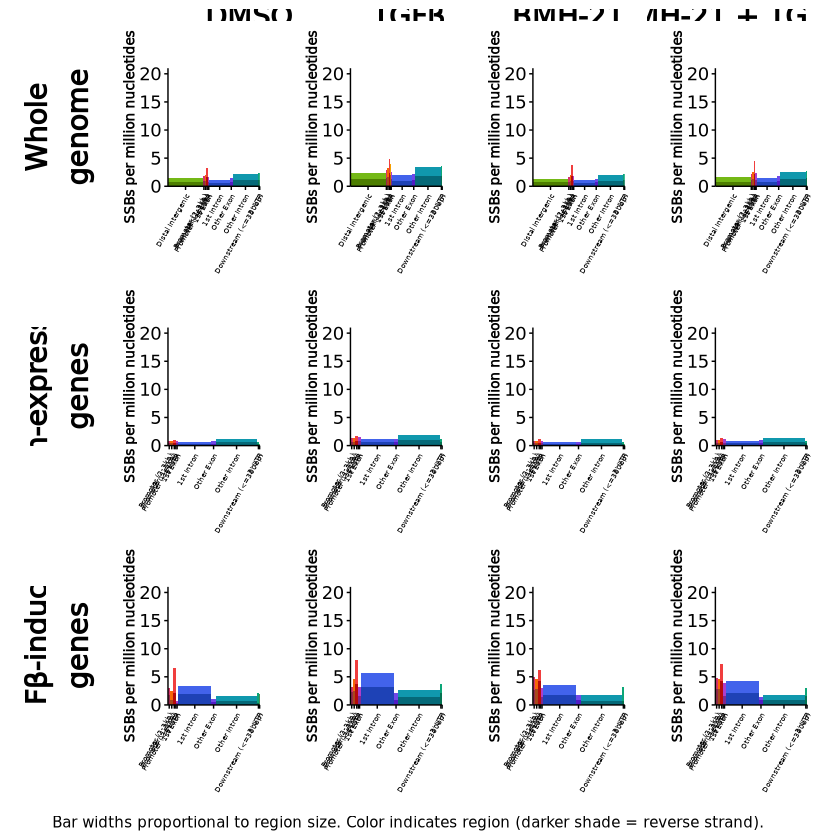

In [38]:
# 3. Define the plotting function
create_frequency_plot <- function(data_file_path, plot_main_title, y_axis_max) {
  plot_ready_data <- read_tsv(data_file_path, show_col_types = FALSE)
  #print(plot_ready_data)
  required_cols <- c("xmin", "xmax", "ymin", "ymax", "calculated_color", "region", "xcenter", "strand")
  if (!all(required_cols %in% names(plot_ready_data))) {
    stop(paste("Data file", data_file_path, "is missing one or more required columns:", paste(setdiff(required_cols, names(plot_ready_data)), collapse=", ")))
  }

  x_coords_df <- plot_ready_data %>%
    distinct(region, xcenter) %>%
    arrange(xcenter)

  pub_plot <- ggplot(plot_ready_data) +
    geom_rect(aes(xmin = xmin, xmax = xmax,
                  ymin = ymin, ymax = ymax,
                  fill = calculated_color)) +
    scale_fill_identity(guide = "none") +
    labs(
      #title = stringr::str_wrap(plot_main_title, width = 70), # Added individual plot title
      y = "SSBs per million nucleotides",
      #x = "Genomic Region", # Explicitly set X-axis label for all plots
      caption = NULL
    ) +
    scale_x_continuous(
      breaks = x_coords_df$xcenter,
      labels = x_coords_df$region,
      expand = c(0, 0)
    ) +
    scale_y_continuous(
      expand = c(0, 0),
      limits = c(0, y_axis_max),
      labels = function(br) { # Multiply breaks by 1,000,000 for display
        format(br * 1e6, scientific = FALSE, nsmall = 0) # nsmall=0 to avoid decimals like 15.0
      }
    ) +

    theme_Publication(base_size = 9) +
    theme(
      axis.text.x = element_text(angle = 60, hjust = 1, size = rel(0.6)),
      axis.text.y = element_text(size = rel(1.5)),
      panel.grid.major.x = element_blank(), 
      panel.grid.minor.x = element_blank(),
      plot.title = element_text(size = rel(0.9), hjust = 0.5),
      axis.title.y = element_text(size = rel(0.9)),
      axis.title.x = element_text(size = rel(0.9))
    )
  return(pub_plot)
}

# 4. Define file paths and titles
base_dir <- "f3_frequency_plots_output_stacked4"

wg_files <- c(
  "SSB_frequency_stacked_region_color_XI-4086-DMSO_plot_data.tsv",
  "SSB_frequency_stacked_region_color_XI-4086-TGF-b_plot_data.tsv",
  "SSB_frequency_stacked_region_color_XI-4086-BMH-21_a_plot_data.tsv",
  "SSB_frequency_stacked_region_color_XI-4086-BMH-21-TGF-b_plot_data.tsv"
)
noexp_files <- c(
  "SSB_frequency_stacked_region_color_NOEXP_XI-4086-DMSO_data.tsv",
  "SSB_frequency_stacked_region_color_NOEXP_XI-4086-TGF-b_data.tsv",
  "SSB_frequency_stacked_region_color_NOEXP_XI-4086-BMH-21_a_data.tsv",
  "SSB_frequency_stacked_region_color_NOEXP_XI-4086-BMH-21-TGF-b_data.tsv"
)
tgfbind_files <- c(
  "SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-DMSO_data.tsv",
  "SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-TGF-b_data.tsv",
  "SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-BMH-21_a_data.tsv",
  "SSB_frequency_stacked_region_color_TGFbInduced_XI-4086-BMH-21-TGF-b_data.tsv"
)

wg_file_paths <- file.path(base_dir, wg_files)
noexp_file_paths <- file.path(base_dir, noexp_files)
tgfbind_file_paths <- file.path(base_dir, tgfbind_files)

file_sets <- list(wg_file_paths, noexp_file_paths, tgfbind_file_paths)

y_maxima_rows <- c(2.1e-5, 2.1e-5, 2.1e-5) # You can still set different y-max per row if needed

condition_display_names <- c("DMSO", "TGFβ", "BMH-21", "BMH-21 + TGFβ")

gene_set_labels_for_titles <- c(
    "Stacked SSB Frequency by Genomic Region",
    "NOEXP - Stacked SSB Frequency by Genomic Region",
    "TGFβ Induced - Stacked SSB Frequency by Genomic Region"
)

# 5. Generate all plots and store them in a matrix
all_plots_matrix <- matrix(list(), nrow = 3, ncol = 4)

for (r in 1:3) {
  current_y_max <- y_maxima_rows[r]
  gene_set_part_of_title <- gene_set_labels_for_titles[r]
  
  for (c in 1:4) {
    data_file <- file_sets[[r]][c]
    
    condition_part_of_title <- paste0("XI-4086-", condition_display_names[c])
    current_plot_title <- paste(condition_part_of_title, "-", gene_set_part_of_title)
    
    p <- create_frequency_plot(data_file, current_plot_title, y_axis_max = current_y_max)
    
    # NO MORE AXIS MODIFICATIONS HERE - each plot keeps its labels
    all_plots_matrix[r, c] <- list(p)
  }
}

# 6. Create header plots for columns and rows
col_header_titles <- c("DMSO", "TGFβ", "BMH-21", "BMH-21 + TGFβ")
row_header_titles <- c("Whole\ngenome", "Non-expressed\ngenes", "TGFβ-induced\ngenes")

col_header_plots <- lapply(col_header_titles, function(title) {
  ggplot() + annotate("text", x = 0.5, y = 0.5, label = title, hjust = 0.5, vjust = 0.5, fontface = "bold", size = 6) + theme_void()
})

row_header_plots <- lapply(row_header_titles, function(title) {
  ggplot() + annotate("text", x = 0.5, y = 0.5, label = title, angle = 90, hjust = 0.5, vjust = 0.5, fontface = "bold", size = 6) + theme_void()
})

empty_plot <- ggplot() + theme_void()

# 7. Assemble the final grid with headers using patchwork
header_row_patch <- Reduce(`|`, c(list(empty_plot), col_header_plots))
data_row1_patch <- Reduce(`|`, c(list(row_header_plots[[1]]), all_plots_matrix[1,]))
data_row2_patch <- Reduce(`|`, c(list(row_header_plots[[2]]), all_plots_matrix[2,]))
data_row3_patch <- Reduce(`|`, c(list(row_header_plots[[3]]), all_plots_matrix[3,]))

final_grid_with_headers <- (header_row_patch) /
                           (data_row1_patch) /
                           (data_row2_patch) /
                           (data_row3_patch) +
  plot_layout(widths = c(0.1, 1, 1, 1, 1), 
              heights = c(0.1, 1, 1, 1))

# 8. Add global caption and display/save
final_plot_output <- final_grid_with_headers +
  plot_annotation(
    caption = "Bar widths proportional to region size. Color indicates region (darker shade = reverse strand)."
  ) &
  theme(plot.caption = element_text(hjust = 0.5, size = 9, margin = margin(t = 10)))

print(final_plot_output)


In [40]:
ggsave("grid_plot_SSB_frequency_all_labels.png", plot = final_plot_output, width = 30, height = 24, dpi = 300)

# get de 

In [191]:
# Read gene-level files
tgb_dmso <- read.table("../DE/FoldChange_TGFb_vs_DMSO.csv", sep=",", header=TRUE)
bmh_dmso <- read.table("../DE/FoldChange_BMH21_vs_DMSO.csv", sep=",", header=TRUE)
bmh_tgb_dmso <- read.table("../DE/FoldChange_BMH21_TGFb_vs_DMSO.csv", sep=",", header=TRUE)
tgb_bmh <- read.table("../DE/FoldChange_TGFb_vs_BMH21.csv", sep=",", header=TRUE)
bmh_tgb_tgb <- read.table("../DE/FoldChange_BMH21_TGFb_vs_TGFb.csv", sep=",", header=TRUE)
bmh_tgb_bmh <- read.table("../DE/FoldChange_BMH21_TGFb_vs_BMH21.csv", sep=",", header=TRUE)

# Read transcript-level files  
tgb_dmso_tx <- read.table("../DE/TranscriptFoldChange_TGFb_vs_DMSO.csv", sep=",", header=TRUE)
bmh_dmso_tx <- read.table("../DE/TranscriptFoldChange_BMH21_vs_DMSO.csv", sep=",", header=TRUE)
bmh_tgb_dmso_tx <- read.table("../DE/TranscriptFoldChange_BMH21_TGFb_vs_DMSO.csv", sep=",", header=TRUE)
tgb_bmh_tx <- read.table("../DE/TranscriptFoldChange_TGFb_vs_BMH21.csv", sep=",", header=TRUE)
bmh_tgb_tgb_tx <- read.table("../DE/TranscriptFoldChange_BMH21_TGFb_vs_TGFb.csv", sep=",", header=TRUE)
bmh_tgb_bmh_tx <- read.table("../DE/TranscriptFoldChange_BMH21_TGFb_vs_BMH21.csv", sep=",", header=TRUE)

# Function to count up/down regulated
count_regulation <- function(df) {
  up <- sum(df$log2FoldChange >= 1.5, na.rm=TRUE)
  down <- sum(df$log2FoldChange <= -1.5, na.rm=TRUE)
  total <- up + down
  return(paste(up, down, total, sep="\t"))
}

# Print results for genes
cat("Gene-level regulation:\n")
cat("TGFb vs DMSO\t", count_regulation(tgb_dmso), "\n")
cat("BMH21 vs DMSO\t", count_regulation(bmh_dmso), "\n") 
cat("BMH21+TGFb vs DMSO\t", count_regulation(bmh_tgb_dmso), "\n")
cat("TGFb vs BMH21\t", count_regulation(tgb_bmh), "\n")
cat("BMH21+TGFb vs TGFb\t", count_regulation(bmh_tgb_tgb), "\n")
cat("BMH21+TGFb vs BMH21\t", count_regulation(bmh_tgb_bmh), "\n")

cat("\nTranscript-level regulation:\n")
cat("TGFb vs DMSO\t", count_regulation(tgb_dmso_tx), "\n")
cat("BMH21 vs DMSO\t", count_regulation(bmh_dmso_tx), "\n")
cat("BMH21+TGFb vs DMSO\t", count_regulation(bmh_tgb_dmso_tx), "\n")
cat("TGFb vs BMH21\t", count_regulation(tgb_bmh_tx), "\n")
cat("BMH21+TGFb vs TGFb\t", count_regulation(bmh_tgb_tgb_tx), "\n")
cat("BMH21+TGFb vs BMH21\t", count_regulation(bmh_tgb_bmh_tx), "\n")

Gene-level regulation:
TGFb vs DMSO	 60	20	80 
BMH21 vs DMSO	 79	78	157 
BMH21+TGFb vs DMSO	 108	115	223 
TGFb vs BMH21	 162	83	245 
BMH21+TGFb vs TGFb	 93	176	269 
BMH21+TGFb vs BMH21	 25	13	38 

Transcript-level regulation:
TGFb vs DMSO	 653	530	1183 
BMH21 vs DMSO	 781	804	1585 
BMH21+TGFb vs DMSO	 777	789	1566 
TGFb vs BMH21	 984	742	1726 
BMH21+TGFb vs TGFb	 711	865	1576 
BMH21+TGFb vs BMH21	 586	544	1130 


In [131]:
install.packages("systemfonts")

Warning message in install.packages("systemfonts"):
“installation of package ‘systemfonts’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [130]:
library(svglite)

ERROR: Error in library(svglite): there is no package called ‘svglite’
